# Alpha Research & Combination

**Research question.** Of thirteen candidate cross-sectional equity factors, which carry statistically robust predictive power for forward returns, and does combining the survivors outperform the best individual factor?

## Overview

This notebook validates a set of price- and statistics-based factors individually, characterises their interactions, and tests several methods of combining them into a single cross-sectional signal. The emphasis is on statistical inference: correcting for the autocorrelation induced by overlapping forward returns, and attaching confidence intervals to every information-coefficient estimate so that a factor is retained only on robust evidence.

## Method

1. **Factor construction** — compute thirteen factors on the S&P 100 universe.
2. **Per-factor validation** — for each factor, estimate the information coefficient (IC) at multiple horizons with Newey–West (HAC) t-statistics and block-bootstrap confidence intervals; examine IC decay, signal diagnostics (autocorrelation, turnover, dispersion, lead–lag), and a backtest at the signal's natural rebalance frequency.
3. **Redundancy analysis** — the cross-factor correlation matrix of daily IC series to identify factors carrying overlapping information.
4. **Combination** — build equal-weight, IC-weighted, and Lasso combinations on a curated factor pair, characterise the chosen signal (same battery of tests as before; horizon, regularization, tear sheet), and stress-test it across market conditions and robustness controls.
5. **Conclusion** — a decision table summarising which factors survive and which combination, if any, is selected.

## 0. Setup

All imports and plotting configurations.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qre.data.historical import HistoricalDataStore
from qre.data.universe import load_sp100
from qre.alpha.factors import (
    BollingerZScore,
    CrossSectionalMomentum,
    LowVol,
    Momentum,
    QualityProxy,
    ResidualMomentum,
    RollingCVaR,
    RollingMaxDrawdown,
    RollingSharpe,
    RollingSkewness,
    RSI,
    SectorNeutralMomentum,
    ShortTermReversal,
)
from qre.alpha.combination import (
    EqualWeightCombiner,
    ICWeightedCombiner,
    LassoCombiner,
)
from qre.analytics import plot_tearsheet
from qre.analytics.ic import block_bootstrap_ci, compute_ic, ic_summary
from qre.analytics.metrics import summary
from qre.analytics.multi_factor_ic import ic_correlation_matrix
from qre.analytics.validation import SignalReport, SignalReportConfig
from qre.backtest.vectorized import VectorizedBacktester

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

## 1. Data and factor construction

The universe is the **S&P 100** — roughly the 100 largest US large-caps — using daily adjusted closes from 2020 to the present. SPY is loaded as a market proxy for the residual-momentum factor (beta removal) but excluded from the cross-section. All factor outputs share the same column set so they can be stacked and combined. Per-ticker coverage and the data's idiosyncrasies are detailed immediately after the loading cell below.

### 1.1 Universe & price panel

Load adjusted daily closes for the S&P 100 (plus SPY as the residual-momentum market proxy), deduplicate Alphabet's dual listing, and split the cross-section off from SPY.

In [6]:
store = HistoricalDataStore(adjustment="adjusted")

# S&P 100 constituents (large caps), intersected with what is cached locally.
sp100 = load_sp100()
cached = set(store.list_tickers("1d"))
UNIVERSE = sorted(t for t in sp100["ticker"] if t in cached and t != "SPY")

# Deduplicate Alphabet's dual listing: keep GOOGL (class A), drop GOOG (class C)
UNIVERSE = [t for t in UNIVERSE if t != "GOOG"]

panel = store.load_panel(UNIVERSE + ["SPY"], "1d")
closes_all = panel["close"]                 # includes SPY (residual momentum input)
closes = closes_all.drop(columns="SPY")     # the cross-section

sector_map = dict(zip(sp100["ticker"], sp100["sector"]))

print(f"Universe: {closes.shape[1]} tickers (+ SPY)")
print(f"Period:   {closes.index.min().date()} to {closes.index.max().date()}")
print(f"Shape:    {closes.shape[0]} days x {closes.shape[1]} tickers")
print(f"Sector map covers {sum(t in sector_map for t in UNIVERSE)}/{closes.shape[1]} tickers")

Universe: 100 tickers (+ SPY)
Period:   2020-01-02 to 2026-06-05
Shape:    1615 days x 100 tickers
Sector map covers 100/100 tickers


### 1.2 History coverage

Surface late listings (IPOs/spin-offs) so we know where the cross-section is thinner. The data idiosyncrasies are discussed immediately below.

In [7]:
# Per-ticker history coverage — surfaces late listings (IPOs, spin-offs).
first_valid = pd.Series({t: closes[t].first_valid_index() for t in closes.columns})
coverage = pd.DataFrame({
    "first_date": first_valid,
    "n_obs": closes.notna().sum(),
    "sector": closes.columns.to_series().map(sector_map),
})
coverage["pct_history"] = (coverage["n_obs"] / len(closes) * 100).round(0)

universe_start = closes.index.min()
partial = (
    coverage[coverage["first_date"] > universe_start + pd.Timedelta(days=5)]
    .sort_values("first_date", ascending=False)
)

print(f"Sector composition ({closes.shape[1]} names):")
print(coverage["sector"].value_counts().to_string())
print(
    f"\n{len(partial)} name(s) listed after {universe_start.date()} "
    f"(partial history):"
)
partial[["first_date", "n_obs", "pct_history", "sector"]]

Sector composition (100 names):
sector
Information Technology    20
Health Care               15
Financials                15
Industrials               15
Consumer Discretionary     9
Consumer Staples           9
Communication Services     8
Energy                     3
Utilities                  3
Real Estate                2
Materials                  1

2 name(s) listed after 2020-01-02 (partial history):


,first_date,n_obs,pct_history,sector
GEV,2024-04-02 04:00:00+00:00,547,34.0,Industrials
PLTR,2020-09-30 04:00:00+00:00,1427,88.0,Information Technology


**Data coverage and idiosyncrasies.**

- **Universe and period.** 100 names drawn from the current S&P 100, over 2020-01-02 to mid-2026 (≈1,615 trading days). Alphabet's dual listing is deduplicated — GOOGL (class A) is kept, GOOG (class C) dropped — so each company appears exactly once. Berkshire Hathaway (BRK.B) is included; its class-share symbol follows the Alpaca dot convention.
- **Survivorship / selection bias.** Membership is the *current* S&P 100 applied to the full history. Names that left the index are absent and present members were selected with hindsight, which biases absolute results upward. This study evaluates *relative* cross-sectional ranking (IC), which is far less sensitive to this than index-level returns — but absolute backtest figures should still be read with the bias in mind.
- **Partial history (late listings).** Two names list after the 2020 start: GE Vernova (GEV), spun off from GE in April 2024 (~34% coverage), and Palantir (PLTR), a September 2020 direct listing (~88%). A name is NaN before it lists, so the cross-section grows from 98 names in early 2020 to 100 from 2024 onward. The IC computation ranks whichever names are live on each date (`min_periods` guard), so this is handled correctly; early-period ICs rest on a marginally smaller cross-section.
- **Dual-class deduplication.** GOOG and GOOGL are one company (Alphabet) in two share classes and track almost identically; keeping both would double-count Alphabet in the IC and double-weight it in the portfolio, so only GOOGL is retained.
- **Sector mapping for sector-neutral momentum.** Every name carries a GICS sector tag (100/100 mapped above), which `SectorNeutralMomentum` uses to demean each stock's momentum against its sector peers. One sector — **Materials** — contains only a single name in this universe (**LIN**, Linde), and a single-name sector has no peers to neutralise against, so the factor masks it to NaN rather than emit an uninformative demeaned-zero. That one stock therefore drops out of the sector-neutral cross-section (99 live names there) while every other factor keeps the full 100.
- **No internal gaps; adjusted prices.** Aside from the late listings there are no missing trading days within any name's history, and all prices are split/dividend-adjusted so returns are clean modulo corporate actions.

### 1.3 The thirteen candidate factors

Construct all thirteen factors with default parameters on a shared column set, and sanity-check each one's first-valid date and coverage. Each is built in its standard orientation (default windows in parentheses); whether that orientation is the *profitable* one is what the per-factor validation in §2 tests.

Citations are tagged **signal** when the cited authors tested the construct as a cross-sectional return predictor, and **measure** when it originates as a risk measure or technical indicator that we repurpose as a signal here — see the note below the list.

**Momentum / trend (5)**
- **Momentum** (252d, skip 21) — trailing ~12-month total return, skipping the most recent month to avoid short-term reversal; classic momentum (signal: Jegadeesh & Titman, 1993).
- **XSMomentum** (252d, skip 21) — the same trailing return demeaned across the cross-section; rank-equivalent to Momentum on this universe (signal: Jegadeesh & Titman, 1993).
- **SectorNeutralMom** (252d, skip 21) — momentum demeaned within each GICS sector, stripping out sector bets (signal: Moskowitz & Grinblatt, 1999).
- **ResidualMom** — momentum of market-beta-residualised returns, i.e. the idiosyncratic component only (signal: Blitz, Huij & Martens, 2011).
- **RollingSharpe** (252d) — trailing return-to-volatility ratio; risk-adjusted momentum, adapted from the volatility-scaled time-series-momentum idea (measure: Moskowitz, Ooi & Pedersen, 2012).

**Mean-reversion / oscillators (3)**
- **RSI** (14d) — Relative Strength Index, an overbought/oversold oscillator (measure: Wilder, 1978).
- **Bollinger** (20d) — z-score of price within its moving-average band (measure: Bollinger, 2001).
- **STReversal** (5d) — negative of the recent one-week return; bets that short-term (weekly) losers rebound (signal: Lehmann, 1990).

**Risk / tail / quality (5)**
- **LowVol** (21d) — inverse trailing volatility; the low-volatility anomaly (signal: Ang, Hodrick, Xing & Zhang, 2006).
- **RollingCVaR** (252d, 5%) — expected shortfall of the worst 5% of trailing daily returns; left-tail risk (measure: Artzner et al., 1999).
- **RollingMaxDD** (252d) — trailing maximum peak-to-trough drawdown (measure: Magdon-Ismail & Atiya, 2004).
- **RollingSkew** (252d) — skewness of the trailing return distribution (signal: Boyer, Mitton & Vorkink, 2010).
- **Quality** (252d) — price-based proxy for fundamental quality (signal: Asness, Frazzini & Pedersen, 2019).

**On the citations.** A *signal* tag means the cited authors tested that construct as a cross-sectional return predictor. A *measure* tag means the construct originates as a risk measure (CVaR, max-drawdown) or a technical indicator (RSI, Bollinger bands), and the SignalReport / time-series momentum citation describes its risk-adjustment lineage rather than a stock-selection test. The *measure* group — RSI, Bollinger, RollingCVaR, RollingMaxDD, and RollingSharpe — has little or no canonical precedent as a standalone cross-sectional alpha: rolling CVaR and max-drawdown signals are effectively our own constructions (downside risk is priced more broadly, e.g. Ang, Chen & Xing, 2006, but not as this specific signal). That makes those factors exploratory by design, which is what §2's validation is meant to adjudicate.

In [ ]:
# All 13 factors with default parameters. ResidualMomentum reads its market
# proxy (SPY) from the price frame and drops it from the output;
# SectorNeutralMomentum needs the GICS sector map. The rest are price-only.
factors = {
    "Momentum":         Momentum(),
    "XSMomentum":       CrossSectionalMomentum(),
    "RSI":              RSI(),
    "Bollinger":        BollingerZScore(),
    "STReversal":       ShortTermReversal(),
    "LowVol":           LowVol(),
    "ResidualMom":      ResidualMomentum(),
    "SectorNeutralMom": SectorNeutralMomentum(sector_map=sector_map),
    "Quality":          QualityProxy(),
    "RollingSharpe":    RollingSharpe(),
    "RollingCVaR":      RollingCVaR(),
    "RollingMaxDD":     RollingMaxDrawdown(),
    "RollingSkew":      RollingSkewness(),
}

# ResidualMomentum needs SPY in its input (market-beta removal); it returns the
# universe with SPY dropped, so every signal shares the same columns.
signals = {}
for name, factor in factors.items():
    prices_in = closes_all if name == "ResidualMom" else closes
    signals[name] = factor.compute(prices_in)

# Sanity check: first valid date, coverage, and column count per factor.
factor_summary = pd.DataFrame({
    name: {
        "first_valid": sig.dropna(how="all").index[0].date(),
        "n_values": int(sig.notna().sum().sum()),
        "cols": sig.shape[1],
    }
    for name, sig in signals.items()
}).T
factor_summary

,first_valid,n_values,cols
Momentum,2020-12-31,135044,100
XSMomentum,2020-12-31,135044,100
RSI,2020-01-23,158844,100
Bollinger,2020-01-30,158344,100
STReversal,2020-01-09,159744,100
LowVol,2020-02-03,158144,100
ResidualMom,2021-04-01,128844,100
SectorNeutralMom,2020-12-31,133681,100
Quality,2020-12-31,135044,100
RollingSharpe,2020-12-31,135044,100


> **Observations.**
> - All thirteen factors build cleanly on the shared 100-name column set, so the signals stack and combine without column misalignment.
> - The first-valid dates expose each factor's lookback. The momentum/risk family (Momentum, XSMomentum, SectorNeutralMom, Quality, RollingSharpe, RollingCVaR, RollingMaxDD, RollingSkew) all start **2020-12-31** on a common 252-day estimation window, while the shorter-window technicals (STReversal, RSI, Bollinger, LowVol) come online within the first month.
> - **ResidualMomentum starts latest (2021-04-01)** — it stacks a rolling market-beta regression on top of a momentum lookback — and so has the fewest observations. Its late start is why ResidualMom is dropped from the kitchen-sink control in §4.7.1: keeping it would push the common evaluation window past the 2022 bear and gut that regime's sample.

## 2. Per-factor validation

Each factor is evaluated with `SignalReport`: IC at multiple horizons with Newey–West t-statistics and block-bootstrap confidence intervals, IC decay, signal diagnostics (autocorrelation, turnover, dispersion, lead–lag), and a backtest at the natural rebalance frequency. Only factors with statistically robust IC will proceed to the combination step.

### 2.1 IC triage across horizons

A fast first screen: mean IC and Newey–West t-statistics at 1/5/21-day horizons. Factors clearing |t_NW| ≥ 2 at some horizon are flagged as survivors for the full battery (triage only).

**Why |t_NW| ≥ 2.** The statistic is the t-stat on the mean daily IC — it asks whether a factor's average rank-correlation with forward returns is reliably different from zero.

- *Newey–West (HAC) standard errors.* Overlapping forward returns at horizons > 1 day make adjacent IC observations serially correlated, which deflates the naive standard error and inflates the t-stat. The NW correction widens the error to absorb that autocorrelation, so a 5- or 21-day t is not spuriously large.
- *Absolute value.* A robustly *negative* IC is as tradable as a positive one — flip the sign and short the factor — so the screen grades the strength of the evidence, not its direction.

|t| ≥ 2 is the conventional ~5% two-sided significance bar, applied here as a deliberately *loose* gate: it uses point estimates (no bootstrap), is computed in-sample over the full window, and makes no multiple-testing correction across the 13 × 3 = 39 tests (e.g. Bonferroni or Benjamini–Hochberg) — which argues for a stricter bar downstream. Clearing it at *some* horizon (not all) is enough, since momentum and risk factors express at different horizons. Passing therefore only earns a factor the full battery in §2.2, where bootstrap CIs and a backtest apply the real scrutiny.

In [ ]:
HORIZONS = [1, 5, 21]

rows = []
for name, signal in signals.items():
    for h in HORIZONS:
        fwd = closes.pct_change(h).shift(-h)
        ic = compute_ic(signal, fwd)
        stats = ic_summary(ic, signal, fwd, horizon=h, n_bootstrap=0)
        rows.append({
            "factor": name,
            "horizon": h,
            "ic": stats["mean"],
            "icir": stats["icir"],
            "t_nw": stats["t_stat_nw"],
        })

tidy = pd.DataFrame(rows)
gate = tidy.pivot(index="factor", columns="horizon", values=["ic", "t_nw"])
gate.columns = [f"{stat}_{h}d" for stat, h in gate.columns]
gate["max_abs_t"] = tidy.groupby("factor")["t_nw"].apply(lambda s: s.abs().max())
gate = gate.sort_values("max_abs_t", ascending=False)

survivors = gate.index[gate["max_abs_t"] >= 2.0].to_list()
print(f"{len(survivors)} factor(s) clear |t_NW| >= 2 (triage only): {survivors}")
gate.round(3)

7 factor(s) clear |t_NW| >= 2 (triage only): ['SectorNeutralMom', 'ResidualMom', 'XSMomentum', 'Momentum', 'RollingSharpe', 'LowVol', 'RollingCVaR']


,ic_1d,ic_5d,ic_21d,t_nw_1d,t_nw_5d,t_nw_21d,max_abs_t
factor,,,,,,,
SectorNeutralMom,0.016,0.016,0.014,3.021,1.866,0.955,3.021
ResidualMom,0.019,0.018,0.022,2.915,1.614,1.232,2.915
XSMomentum,0.020,0.020,0.017,2.655,1.547,0.798,2.655
Momentum,0.020,0.020,0.017,2.655,1.547,0.798,2.655
RollingSharpe,0.018,0.018,0.017,2.601,1.547,0.854,2.601
LowVol,-0.007,-0.030,-0.056,-1.005,-2.281,-2.359,2.359
RollingCVaR,-0.013,-0.033,-0.059,-1.471,-2.095,-2.032,2.095
RollingMaxDD,-0.004,-0.023,-0.042,-0.526,-1.704,-1.743,1.743
Quality,-0.001,-0.003,-0.011,-0.217,-0.415,-0.796,0.796


> **Observations.**
> - Seven factors clear the |t_NW| ≥ 2 triage screen: the momentum cluster (SectorNeutralMom, ResidualMom, XSMomentum, Momentum, RollingSharpe) with **positive** IC, and two risk factors (LowVol, RollingCVaR) with **negative** IC. The remaining six never reach significance at any horizon.
> - This sorts the §1.3 framing: of the *measure*-tagged exploratory factors, only RollingCVaR and RollingSharpe survive — RSI, Bollinger, RollingMaxDD, and RollingSkew all wash out — so the surviving set is dominated by *signal*-tagged constructs with prior cross-sectional evidence.
> - The two families peak at **opposite ends of the scanned horizons**. Momentum's IC is strongest at 1 day (t_NW ≈ 2.6–3.0) and fades by 21 days; LowVol and RollingCVaR are insignificant at 1 day but strengthen monotonically to their most negative IC at 21 days (t_NW ≈ −2.0 to −2.4). The momentum edge is fast, the risk edge slow.
> - **Caveat: 21 days is the longest horizon tested here**, so the risk factors being "most negative at 21d" may be a boundary artifact of the horizon grid rather than a true peak — their IC could keep strengthening past 21d. §4.3 extends the scan to 63 days to locate where the slow edge actually lives.
> - The negative sign on LowVol/RollingCVaR means high-risk names *out*-performed over 2020–2026, consistent with a bull-dominated sample. Whether that sign is stable or a regime artifact is what §4.6 tests; here it only earns the factor a place in the battery.
> - Momentum and XSMomentum report identical statistics, confirming they are rank-equivalent (§3 shows IC corr ≈ 1).

### 2.2 Full validation battery on survivors

Run the complete `SignalReport` on each survivor: IC at multiple horizons with bootstrap CIs, IC decay, diagnostics, and a backtest at the natural rebalance frequency.

In [10]:
cfg = SignalReportConfig(n_bootstrap=5000, ic_decay_max_lag=21)

reports = {}
for name in survivors:
    print(f"running {name} ...", flush=True)
    reports[name] = SignalReport(signals[name], closes, name=name, config=cfg).run()
print("done")


running SectorNeutralMom ...
running ResidualMom ...
running XSMomentum ...
running Momentum ...
running RollingSharpe ...
running LowVol ...
running RollingCVaR ...
done


In [ ]:
def ic_ci(ibh, h):
    row = ibh.loc[h]
    return f"{row['mean']:+.3f} [{row['ci_lower']:+.3f}, {row['ci_upper']:+.3f}]"


rows = []
for name, rep in reports.items():
    r = rep.results
    ibh = r["ic_by_horizon"].set_index("horizon")
    rows.append({
        "factor": name,
        "IC@1d (95% CI)": ic_ci(ibh, 1),
        "IC@21d (95% CI)": ic_ci(ibh, 21),
        "nat_freq": r["natural_freq"],
        "Sharpe(1d)": round(r["sharpe_daily"], 2),
        "Sharpe(nat)": round(r["sharpe_natural"], 2),
    })

report_table = pd.DataFrame(rows).set_index("factor")
report_table

,IC@1d (95% CI),IC@21d (95% CI),nat_freq,Sharpe(1d),Sharpe(nat)
factor,,,,,
SectorNeutralMom,"+0.016 [+0.006, +0.026]","+0.014 [-0.015, +0.044]",1,0.52,0.52
ResidualMom,"+0.019 [+0.007, +0.032]","+0.022 [-0.012, +0.059]",1,0.35,0.35
XSMomentum,"+0.020 [+0.005, +0.035]","+0.017 [-0.026, +0.060]",1,0.17,0.17
Momentum,"+0.020 [+0.005, +0.035]","+0.017 [-0.026, +0.060]",1,0.54,0.54
RollingSharpe,"+0.018 [+0.004, +0.032]","+0.017 [-0.023, +0.057]",1,0.16,0.16
LowVol,"-0.007 [-0.022, +0.007]","-0.056 [-0.105, -0.010]",4,-1.24,-1.15
RollingCVaR,"-0.013 [-0.030, +0.004]","-0.059 [-0.113, -0.000]",4,-0.97,-0.98


> **Observations.**
> - **The bootstrap CIs split the survivors into two reliability tiers.** At 1 day, all five momentum factors have CIs that exclude zero (e.g. Momentum +0.020 [+0.005, +0.035]); the two risk factors do *not* (RollingCVaR −0.013 [−0.030, +0.004]). At 21 days the picture inverts — the risk factors' CIs now exclude zero (RollingCVaR −0.059 [−0.113, −0.000]) while the momentum factors' 21d CIs straddle it. Each family is reliable only at its own horizon, confirming the fast/slow split from triage.
> - **`natural_freq` recovers the same split mechanically:** 1-day for every momentum factor, 4-day for the two risk factors — the reliability-weighted picker lands the momentum edge at daily and pushes the risk edge out, with no horizon hard-coded.
> - **IC rank ≠ Sharpe rank.** Among the momentum factors, Momentum and SectorNeutralMom post Sharpe ≈ 0.52–0.54 while XSMomentum and RollingSharpe — same-signed, similar IC — manage only ≈ 0.16–0.17. Identical ordinal IC, very different magnitude-weighted payoff: the rank-vs-magnitude (cardinal sizing) gap flagged for future work.
> - **The risk factors are robustly *un*profitable as built** (LowVol Sharpe −1.24, RollingCVaR −0.98) — exactly what a negative IC predicts. That makes them useful only if a sign-aware combiner flips them, which §4 tests directly.

### 2.3 Example reports: Momentum vs RollingCVaR

Full text-and-figure reports for one strong momentum factor and one negative-IC risk factor. The two factors carried forward are Sector-Neutral Momentum and Rolling Low Volatility.


  Signal Report: RollingCVaR

  Diagnostics
  ────────────────────────────────────────
  Lag-1 autocorrelation:     0.998  ⚠ quasi-static
  Mean daily turnover:      0.003  ⚠ very low
  Mean dispersion:          0.014

  IC by Horizon
  ────────────────────────────────────────────────────────
  Horizon   Mean IC    ICIR   t-stat    t(NW)            95% CI
  ────────────────────────────────────────────────────────
      1d   -0.0128   -0.04    -1.47    -1.47  [-0.030, +0.004]
      5d   -0.0329   -0.10    -3.82    -2.09  [-0.064, -0.001]
     10d   -0.0413   -0.13    -4.91    -1.95  [-0.082, +0.003]
     21d   -0.0586   -0.20    -7.49    -2.03  [-0.113, -0.000]

  Backtest Comparison (cost = 10 bps)
  ────────────────────────────────────────
  Natural rebalance freq:  4d
  Sharpe (daily):          -0.972
  Sharpe (4d rebal):      -0.978

  Lead-Lag Profile
  ────────────────────────────────────────
  Strongest lead (predictive): offset +10  IC = -0.0122
  Strongest lag (reactive):    o

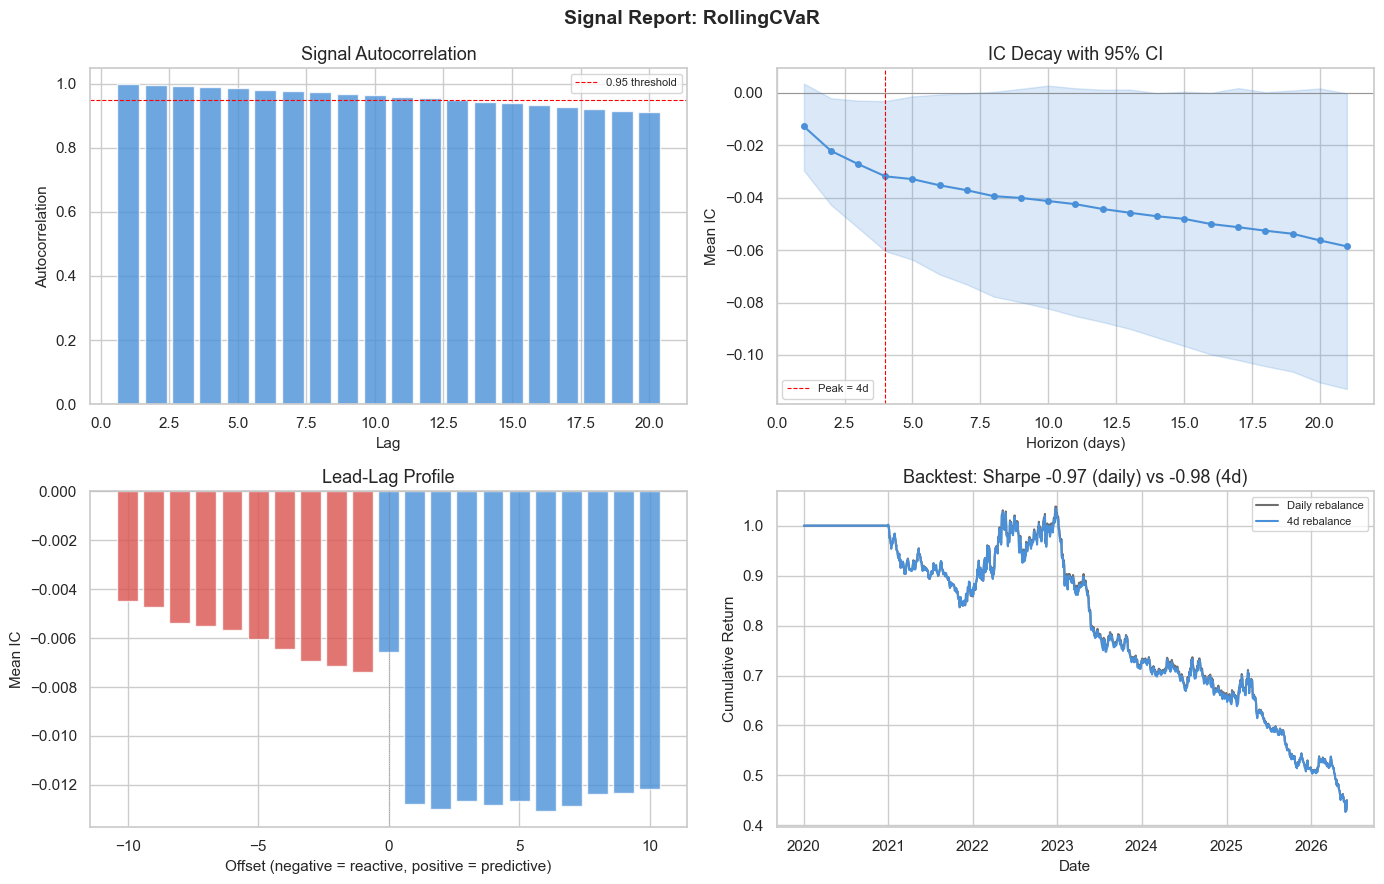

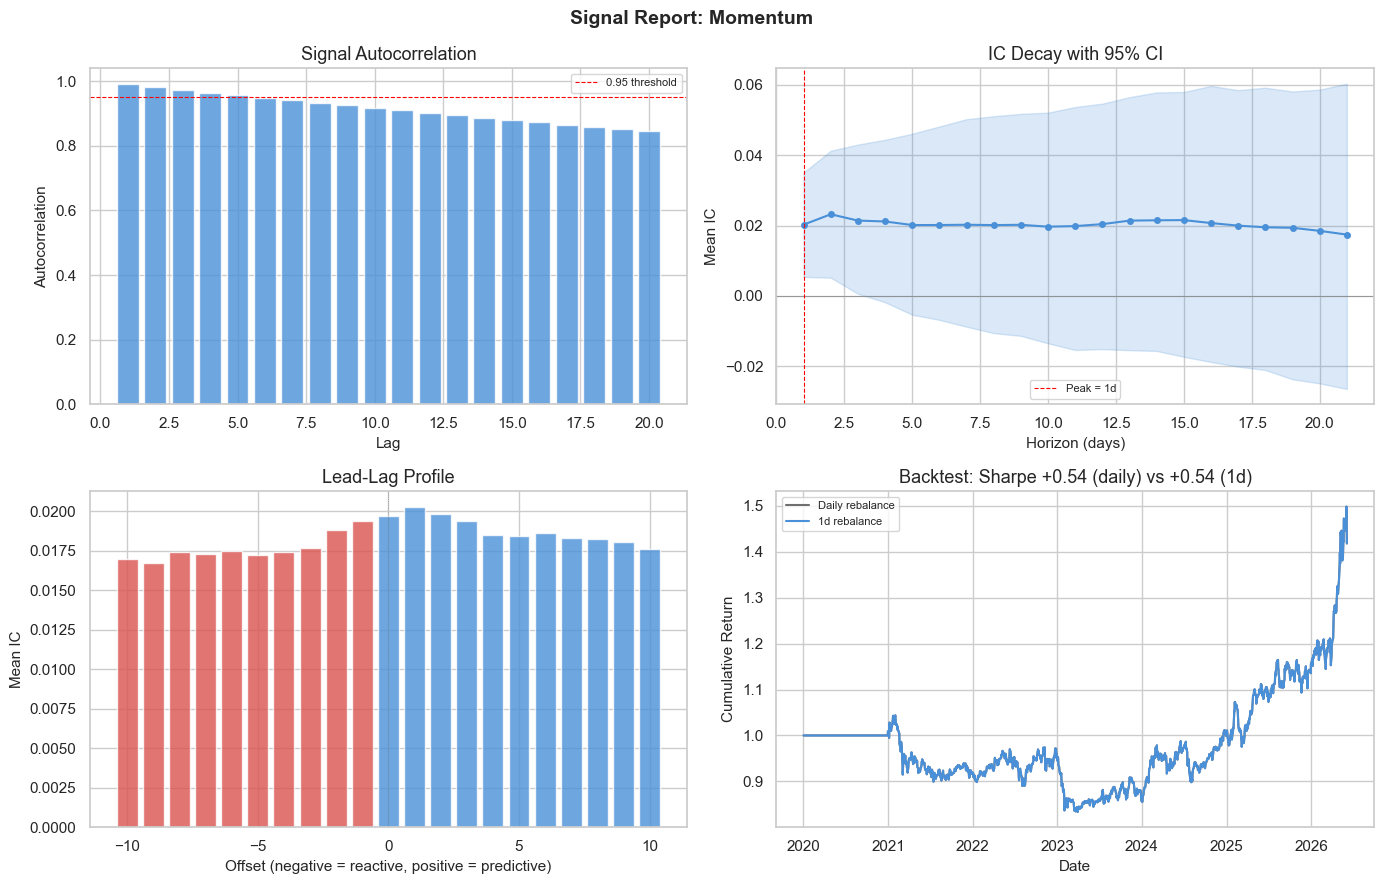

In [32]:
for name in ["RollingCVaR", "Momentum"]:
    reports[name].print_summary()
    reports[name].plot()

> **Observations.**
> - **This pair is the clearest demonstration of the Newey–West correction.** Both factors show naive t-stats that balloon with horizon — RollingCVaR reaches −7.49 at 21d, Momentum holds ≈ 2.8 out to 21d — but the HAC-corrected t(NW) collapses them: CVaR to ≈ −2.0 and Momentum to **0.80**. The naive statistic ignores the autocorrelation that overlapping 21-day returns inject; NW, and the bootstrap CIs, reveal the longer-horizon "significance" is largely an overlap artifact.
> - **The IC-decay curves are horizon mirror images.** RollingCVaR decays roughly *linearly and keeps getting more negative* with lag; its CI band straddles zero at most lags and sits cleanly below zero only around the early lags (≈ 4), which is where `natural_freq` lands. The deepening magnitude is actually favourable for a sign-aware combiner — a stronger, reliably-signed negative IC is something the combiner can flip into a positive contribution. Momentum's decay is nearly flat at ≈ +0.02, but its CI bands begin admitting zero after just 2–3 days, so its reliability is concentrated at the 1-day horizon (`natural_freq` = 1).
> - **The "quasi-static / very low turnover" flags are expected.** Both use 252-day windows, so lag-1 autocorrelation ≈ 0.99 and CVaR's 0.003 turnover simply reflect slow-moving inputs; the daily book still harvests the edge through position persistence (daily and natural-frequency Sharpes are near-identical for both).
> - **Lead–lag: CVaR is mildly forward-looking, Momentum is symmetric.** RollingCVaR's profile is roughly uniform at ≈ −0.006 on the reactive (past-return) side but deeper, ≈ −0.013, on the predictive (future-return) side — in absolute terms it correlates more with the returns it *precedes* than the ones it *follows*, a desirable (if modest) property for a predictive signal. Momentum's profile is near-symmetric (+1 lead +0.0202 vs −1 lag +0.0194): built from trailing returns, it anticipates and echoes returns about equally.
> - **Dispersion exposes the rank-vs-magnitude gap.** RollingCVaR's signal dispersion is 0.014 versus Momentum's 0.353 — expected-shortfall values are tiny negatives clustered tightly together, so cardinal (magnitude) sizing can barely separate names even where rank-IC still grades them.

## 3. Cross-factor IC correlation

The K×K correlation of the daily IC series across all 13 factors shows which are *right on the same days*. This is the notion of redundancy that matters for combination: two factors with highly correlated IC carry the same information and should not both enter at full weight, whereas low (or negative) correlation means genuine diversification. Computed at the 1-day horizon, where the momentum family's edge concentrates. The momentum flavours should cluster tightly (Momentum and XSMomentum are rank-equivalent, so their IC correlation is ≈ 1), while RollingCVaR should sit apart as an independent, risk-based source.

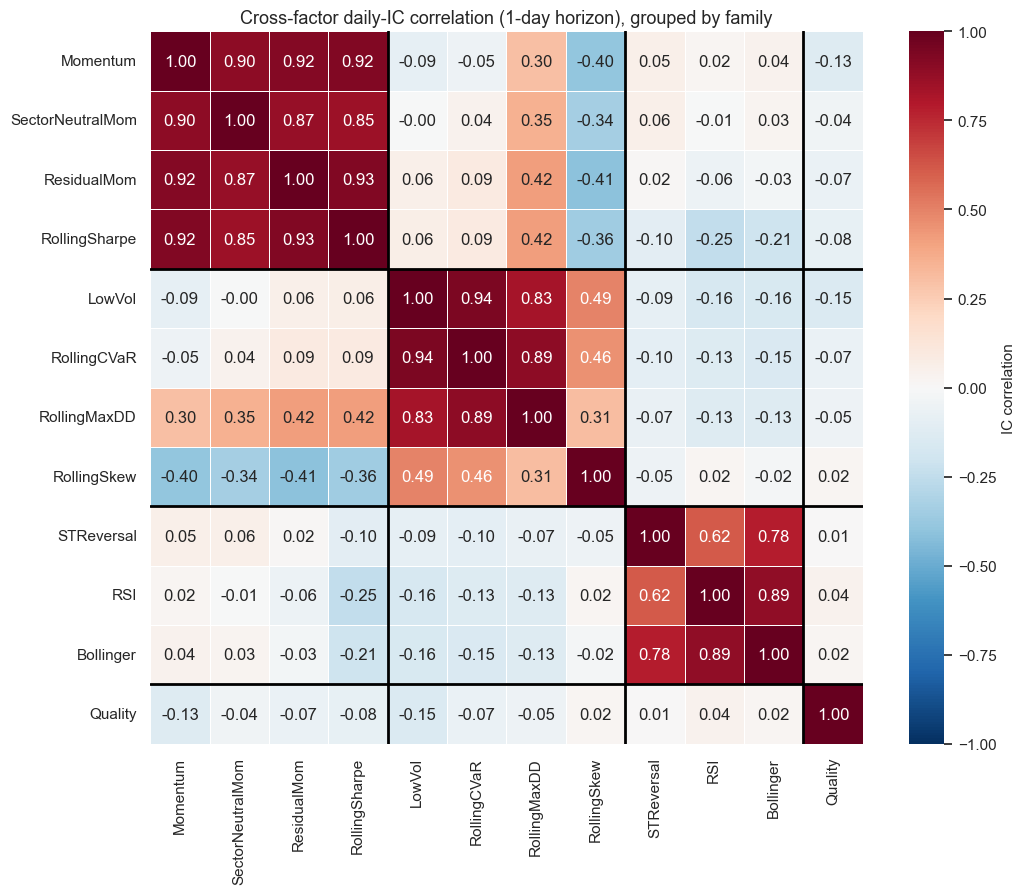

In [13]:
# Ordered by family so the block structure is visible; XSMomentum is omitted
# as a rank-duplicate of Momentum (IC corr ~= 1).
FAMILIES = {
    "Momentum/Trend": ["Momentum", "SectorNeutralMom", "ResidualMom",
                       "RollingSharpe"],
    "Risk/Tail":      ["LowVol", "RollingCVaR", "RollingMaxDD", "RollingSkew"],
    "Reversal":       ["STReversal", "RSI", "Bollinger"],
    "Quality":        ["Quality"],
}
order = [f for fam in FAMILIES.values() for f in fam]

ic_corr = ic_correlation_matrix(signals, closes, horizon=1).loc[order, order]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    ic_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={"label": "IC correlation"}, ax=ax,
)

for b in np.cumsum([len(v) for v in FAMILIES.values()])[:-1]:
    ax.axhline(b, color="black", lw=2)
    ax.axvline(b, color="black", lw=2)

ax.set_title("Cross-factor daily-IC correlation (1-day horizon), grouped by family")
plt.tight_layout()

> **Observations.**
> - **The block-diagonal structure is confirmed** The momentum/trend factors are mutually correlated at **0.85–0.93** (Momentum–ResidualMom 0.92, –RollingSharpe 0.92); the vol/tail factors cluster nearly as tightly (LowVol–RollingCVaR **0.94**, –RollingMaxDD 0.83); and the reversal factors form a third block (RSI–Bollinger **0.89**, Bollinger–STReversal 0.78). Quality sits apart, near-zero against everything (|corr| ≤ 0.15).
> - **The combination pairing is vindicated: momentum and CVaR are essentially independent in IC.** SectorNeutralMom–RollingCVaR is **+0.04** (Momentum–CVaR −0.05) — the two axes are right on different days, so pairing them in §4 combines genuinely diversifying information rather than re-weighting one source. This is the redundancy notion that matters for combination.
> - **Two dilutions complicate the "risk" block.** RollingMaxDD correlates **+0.30 to +0.42** with the momentum factors — a deep-drawdown stock is also a momentum loser, so it straddles both axes rather than being pure risk. RollingSkew runs *anti*-momentum (**−0.34 to −0.41**) and only loosely joins the vol block (~0.46). So the momentum family is far more internally coherent than the risk family, which is a loose confederation of distinct tail statistics.

## 4. Combination

Three combiners — equal-weight, IC-weighted, and rolling Lasso — are built on a curated two-factor pair, compared head-to-head, and then the chosen signal is characterised (horizon, regularization, tear sheet) and stress-tested (regimes, controls, IC-weighting diagnostics).

- **EqualWeight** — average of the cross-sectionally z-scored signals; the robust, hardest-to-overfit baseline. *No parameters.* Assumes every factor is positively oriented, so it cannot flip a negative-IC input.
- **ICWeighted** — weights each factor by its trailing mean IC with the *sign preserved*, so a negative-IC factor is flipped (shorted) rather than applied in its losing direction. Parameters: `shrinkage=0.0` (keep the raw signed weights, no pull toward equal weight), `lookback=252` (trailing-IC window).
- **Lasso** — rolling L1-penalised regression of forward returns on the z-scored signals; redundant factors' coefficients are driven to exactly zero while survivors keep their calibrated magnitude. Parameters: `alpha=0.001` (small penalty, mid-plateau — see §4.4), `lookback=252` (training window).

### 4.1 Constructing the three combiners

Combine a momentum representative (SectorNeutralMom) with the risk/tail axis (LowVol), feeding LowVol **raw** (it has negative IC) on purpose: the sign-aware combiners must learn to flip it from trailing data, while equal-weight cannot — that contrast is the first result.

**Why LowVol for the risk axis.** LowVol is the established low-volatility anomaly (Ang, Hodrick, Xing & Zhang, 2006) — a studied, well-evidenced cross-sectional factor — and it is marginally the stronger risk factor on our own IC table: higher peak |t_NW| (2.36 vs 2.10), a 21-day CI that excludes zero more cleanly, and a more negative standalone Sharpe (−1.24 vs −0.97, a stronger signal once flipped). It is 94% IC-correlated with RollingCVaR (§3) — near-interchangeable in *rank* — but the two are not identical: LowVol is a smoother risk estimate (full-distribution volatility over 252 days) than CVaR (an order statistic on only the worst ~5% of days), which plausibly gives a cleaner, more stable defensive ranking. (The combiners z-score every input before use, so this is a ranking difference, not a scale or dispersion effect.) The §4.7.3 control swaps the two head-to-head and confirms LowVol yields a materially more all-weather, bear-robust combination. CVaR — the more *exploratory* tail-risk construct — remains in the kitchen-sink control (§4.7.1).

Parameter choices: `shrinkage=0` keeps ICWeighted's signed weights so a negative-IC factor is flipped rather than pulled back toward equal weight; `alpha=0.001` is small because daily forward returns (~1e-2) are tiny against the z-scored features (~1), so a larger penalty zeros the coefficients out. This is tested more rigorously in §4.4.

In [34]:
combo_inputs = {
    "SectorNeutralMom": signals["SectorNeutralMom"],
    "LowVol":           signals["LowVol"],
}

combined = {
    "EqualWeight": EqualWeightCombiner().combine(combo_inputs),
    "ICWeighted":  ICWeightedCombiner(shrinkage=0.0).combine(combo_inputs, closes),
    "Lasso":       LassoCombiner(alpha=0.001).combine(combo_inputs, closes),
}

for name, sig in combined.items():
    cov = sig.notna().any(axis=1).sum()
    print(f"{name:12} non-empty rows: {cov:>5}  /  {len(sig)}")

EqualWeight  non-empty rows:  1594  /  1615
ICWeighted   non-empty rows:  1342  /  1615
Lasso        non-empty rows:  1362  /  1615


> **Observations.**
> - **EqualWeight covers the most (1594 rows).** It only averages z-scored inputs (nanmean), so it produces a value as soon as *either* factor is live — and LowVol comes online in Feb 2020 (22-day window), so the combiner inherits its earliest-starting input.
> - **Lasso (1362) is gated by SectorNeutralMom.** Its 252-day training window needs both factors present, and SNM warms up in Dec 2020, so the Lasso cannot start earlier despite LowVol's early data.
> - **ICWeighted (1342) is the latest-warming combiner — online ~Feb 2021** — needing a 252-day trailing-IC window stacked on the factors' warmup. Its first-valid date would naturally set `common_start`; §4.2 floors it at **2021-12-31** so the full evaluation sample partitions cleanly into the 2022 bear and 2023–26 bull, discarding ~11 months of early-2021 data that would otherwise fall outside both regimes.

### 4.2 Head-to-head: combiners vs raw inputs

Evaluate the three combined signals against their raw inputs on a common window (set by the longest combiner warmup), with the full validation battery and a PnL comparison.

In [37]:
eval_signals = {
    "SectorNeutralMom": signals["SectorNeutralMom"],   # raw baseline
    "LowVol":           signals["LowVol"],             # raw baseline
    **combined,                                         # Equal / IC / Lasso
}

# LowVol's early warmup pulls the natural common window back to ~Feb 2021; floor
# it at the bear start so the full sample partitions cleanly into the 2022 bear
# and 2023-26 bull.
natural_start = max(s.first_valid_index() for s in eval_signals.values())
common_start = max(natural_start, pd.Timestamp("2021-12-31", tz=closes.index.tz))
closes_eval = closes.loc[common_start:]
print(f"Common window: {common_start.date()} -> {closes_eval.index.max().date()} "
    f"({len(closes_eval)} days)")

Common window: 2021-12-31 -> 2026-06-05 (1111 days)


In [ ]:
# The comparison table shows only point estimates, so skip the bootstrap CIs.
cmp_cfg = SignalReportConfig(n_bootstrap=0, ic_decay_max_lag=21)
comp_reports = {}
for name, sig in eval_signals.items():
    print(f"running {name} ...", flush=True)
    comp_reports[name] = SignalReport(
        sig.loc[common_start:], closes_eval, name=name, config=cmp_cfg
    ).run()
print("done")

running SectorNeutralMom ...
running LowVol ...
running EqualWeight ...
running ICWeighted ...
running Lasso ...
done


In [39]:
rows = []
for name, rep in comp_reports.items():
    r = rep.results
    ibh = r["ic_by_horizon"].set_index("horizon")
    pnl_1d  = (1 + r["backtest_daily"]).prod() - 1
    pnl_nat = (1 + r["backtest_natural"]).prod() - 1
    rows.append({
        "signal":       name,
        "IC@1d":        round(ibh.loc[1, "mean"], 4),
        "ICIR@1d":      round(ibh.loc[1, "icir"], 2),
        "IC@21d":       round(ibh.loc[21, "mean"], 4),
        "nat_freq":     r["natural_freq"],
        "Sharpe(1d)":   round(r["sharpe_daily"], 2),
        "Sharpe(nat)":  round(r["sharpe_natural"], 2),
        "PnL(1d)":      round(pnl_1d, 3),
        "PnL(nat)":     round(pnl_nat, 3),
    })
comparison = pd.DataFrame(rows).set_index("signal")
comparison

,IC@1d,ICIR@1d,IC@21d,nat_freq,Sharpe(1d),Sharpe(nat),PnL(1d),PnL(nat)
signal,,,,,,,,
SectorNeutralMom,0.0203,0.10,0.0269,15,0.80,0.82,0.418,0.419
LowVol,-0.0119,-0.04,-0.0612,21,-1.38,-1.18,-0.569,-0.512
EqualWeight,0.0047,0.02,-0.0198,21,-0.71,-0.54,-0.294,-0.228
ICWeighted,0.0239,0.09,0.0672,20,0.97,0.97,0.701,0.679
Lasso,0.0171,0.06,0.0672,21,0.98,0.89,0.690,0.592


> **Observations.**
> - **Equal-weight fails — it cannot flip a negative-IC factor.** Averaging SectorNeutralMom (+IC) with *raw* LowVol (−IC) lets the two partially cancel: EqualWeight posts IC@1d 0.005, Sharpe(nat) −0.54, PnL −0.23 — worse than either input oriented correctly. Feeding LowVol raw poisons the blind combiner; this is the first result.
> - **Both sign-aware combiners flip LowVol and clear the bar.** ICWeighted and Lasso each learn LowVol's negative orientation and beat the best single input (SectorNeutralMom: Sharpe(nat) 0.82). ICWeighted reaches Sharpe(nat) **0.97** (PnL 0.68, and the highest IC@1d at 0.024); Lasso reaches **0.89** (PnL 0.59). Combination beats best-single-factor on risk-adjusted return.
> - **ICWeighted edges Lasso.** Both keep LowVol flipped, but the signed-IC weighting lands a higher full-sample Sharpe and IC than the L1-penalised Lasso — likely because the penalty shrinks the defensive leg slightly. The two are close (0.97 vs 0.89), and which is the better *all-weather* signal is decided by the regime split in §4.6, not full-sample Sharpe.
> - **Every combiner's `nat_freq` pins near the 20–21d scan boundary,** so the reported natural frequency is an artifact of the 21-lag scan; §4.3 extends it to 63 days to find where the edge actually lives before a horizon is frozen.

### 4.3 Horizon analysis & natural frequency

Extend the IC-decay scan to 63 days to find where each combiner's edge actually lives and where it stops being reliable (earlier scans capped at 21 hit the boundary). Both candidate signals are profiled — the Lasso (§4.3a) and ICWeighted (§4.3b), since we may carry both forward — and the reliable band sets the frozen rebalance horizon (`FREEZE_HORIZON`) reused by the regime and robustness analyses.

**How `natural_freq` is chosen.** `SignalReport` does *not* return the horizon with the highest raw IC — for a monotone-rising decay that would simply pin to the scan's boundary. Instead it scores each lag in the IC-decay scan by a block-bootstrap t-statistic, |mean IC| / standard error, where the bootstrap uses a block length equal to the lag (so it HAC-corrects for the overlap of multi-day forward returns), and returns the lag with the largest such t. This rewards horizons whose IC is both large *and* reliable, down-weighting long horizons whose point estimate is big but whose standard error has blown up. (Fallbacks: |IC| argmax when the bootstrap is off, and 1 day when the decay is degenerate.)


#### 4.3a Lasso

Deep IC-decay report for the Lasso (SectorNeutralMom + LowVol).



  Signal Report: Lasso (deep)

  Diagnostics
  ────────────────────────────────────────
  Lag-1 autocorrelation:     0.968  ⚠ quasi-static
  Mean daily turnover:      0.163
  Mean dispersion:          0.026

  IC by Horizon
  ────────────────────────────────────────────────────────
  Horizon   Mean IC    ICIR   t-stat    t(NW)            95% CI
  ────────────────────────────────────────────────────────
      1d   +0.0171    0.06     2.13     2.13  [+0.002, +0.033]
      5d   +0.0356    0.14     4.54     2.52  [+0.009, +0.064]
     10d   +0.0491    0.19     6.42     2.57  [+0.013, +0.087]
     21d   +0.0672    0.29     9.64     2.73  [+0.019, +0.116]
     30d   +0.0725    0.31    10.30     2.48  [+0.019, +0.132]
     42d   +0.0738    0.31    10.02     2.13  [+0.008, +0.145]
     63d   +0.0904    0.40    12.90     2.38  [+0.010, +0.165]

  Backtest Comparison (cost = 10 bps)
  ────────────────────────────────────────
  Natural rebalance freq:  20d
  Sharpe (daily):          +0.981
  Sha

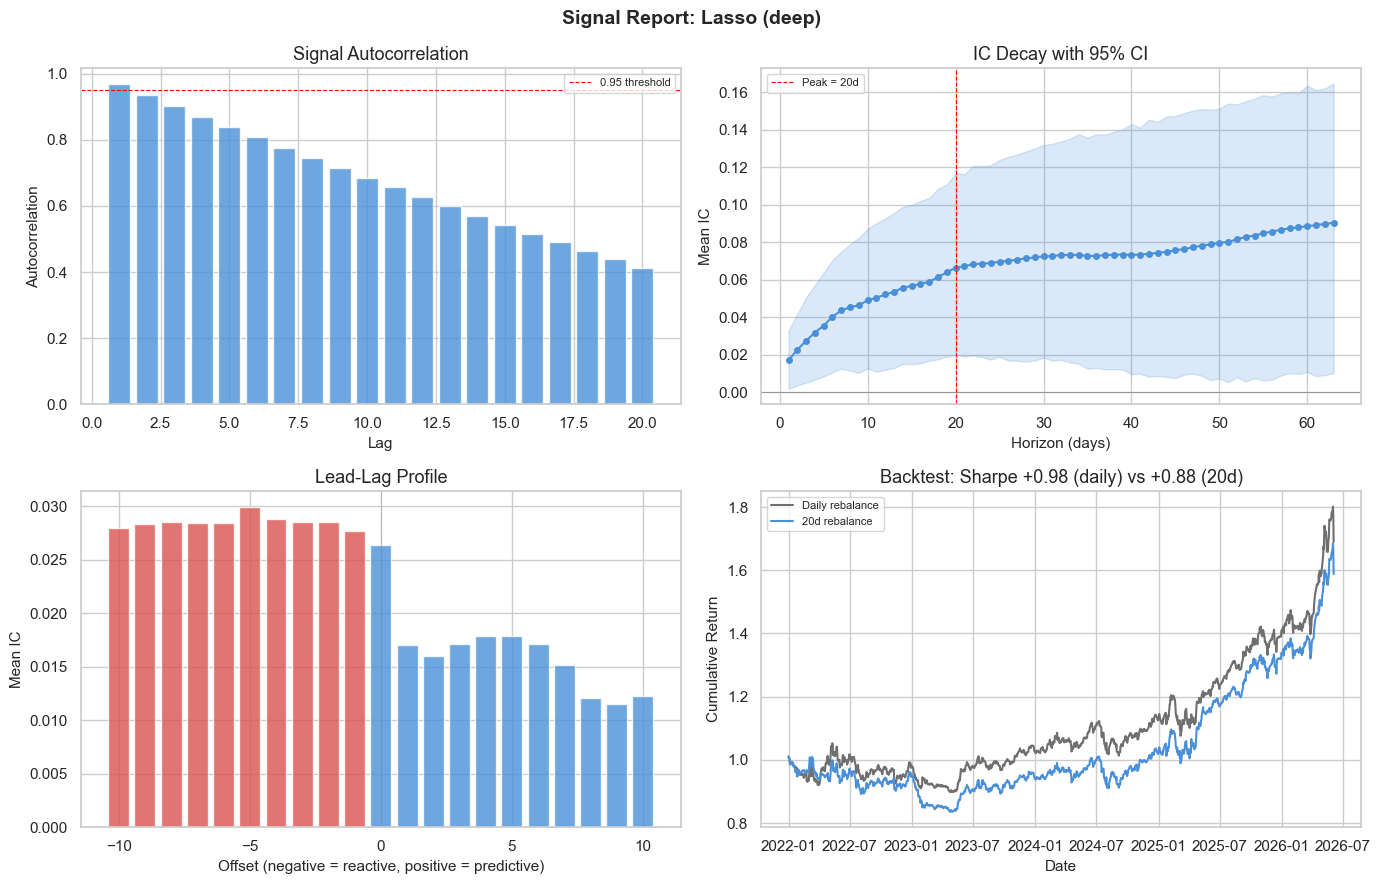

In [40]:
deep_cfg = SignalReportConfig(
    horizons=[1, 5, 10, 21, 30, 42, 63],
    ic_decay_max_lag=63,
    n_bootstrap=5000,   # drop to 2000 if the 63-lag CI loop is too slow
)
lasso_sig = combined["Lasso"].loc[common_start:]   # alpha=0.001 Lasso on the common window
lasso_deep = SignalReport(lasso_sig, closes_eval, name="Lasso (deep)", config=deep_cfg).run()
lasso_deep.print_summary()
_ = lasso_deep.plot()

> **Observations.**
> - **The Lasso's edge is reliable at every scanned horizon.** Mean IC rises *smoothly* from +0.017 (1d) to +0.090 (63d), and the HAC t-stat stays **≥ 2.1 throughout**, peaking at **2.73 at 21d** — every 95% CI excludes zero. On the decay plot the CI band's gap above zero widens until ~20d and then narrows as the independent sample shrinks, but never touches zero: the edge is strongest and most reliable around the 3-week mark.
> - **Read the NW column, not the naive t.** The raw t-stat balloons to 12.9 at 63d — overlapping-return inflation; the NW-corrected ~2.1–2.7 is the honest read.
> - **`natural_freq` lands at 20d, and the HAC-corrected reliability peaks around the 3-week mark** (21d t_NW 2.73) — where the IC is both large and most trustworthy.
> - **Diagnostics.** Lag-1 autocorrelation 0.968 (quasi-static — expected for 252-day-lookback inputs, harvested through position persistence), turnover 0.16, dispersion 0.026. The low dispersion is a *scale* artifact: the Lasso standardizes its regression target, so the fitted coefficients — and thus the combined signal's values — are tiny (~1e-3). It carries no performance meaning; both the rank-based IC and the scale-invariant backtester (demean + unit-gross) ignore overall signal scale.
> - **The signal leans reactive.** Lead-lag is roughly uniform on each side but stronger on the reactive/past-return side (~+0.028) than the predictive/future-return side (~+0.015) — momentum-family behaviour, so much of the long-horizon IC is persistence of an already-formed tilt rather than fresh forecasting. These are full-sample figures on a bull-dominated window, so they speak to the bull more than to all-weather robustness.


#### 4.3b ICWeighted

Deep IC-decay report for the ICWeighted combiner, on the same 63-day scan (`deep_cfg`, defined in §4.3a).



  Signal Report: ICWeighted (deep)

  Diagnostics
  ────────────────────────────────────────
  Lag-1 autocorrelation:     0.974  ⚠ quasi-static
  Mean daily turnover:      0.132
  Mean dispersion:          0.816

  IC by Horizon
  ────────────────────────────────────────────────────────
  Horizon   Mean IC    ICIR   t-stat    t(NW)            95% CI
  ────────────────────────────────────────────────────────
      1d   +0.0239    0.09     2.96     2.96  [+0.008, +0.040]
      5d   +0.0398    0.16     5.19     2.93  [+0.013, +0.066]
     10d   +0.0527    0.22     7.22     2.92  [+0.016, +0.089]
     21d   +0.0672    0.31    10.18     2.94  [+0.022, +0.112]
     30d   +0.0679    0.31    10.24     2.55  [+0.017, +0.121]
     42d   +0.0665    0.29     9.52     2.03  [+0.003, +0.131]
     63d   +0.0780    0.34    11.14     1.97  [-0.008, +0.147]

  Backtest Comparison (cost = 10 bps)
  ────────────────────────────────────────
  Natural rebalance freq:  7d
  Sharpe (daily):          +0.971
 

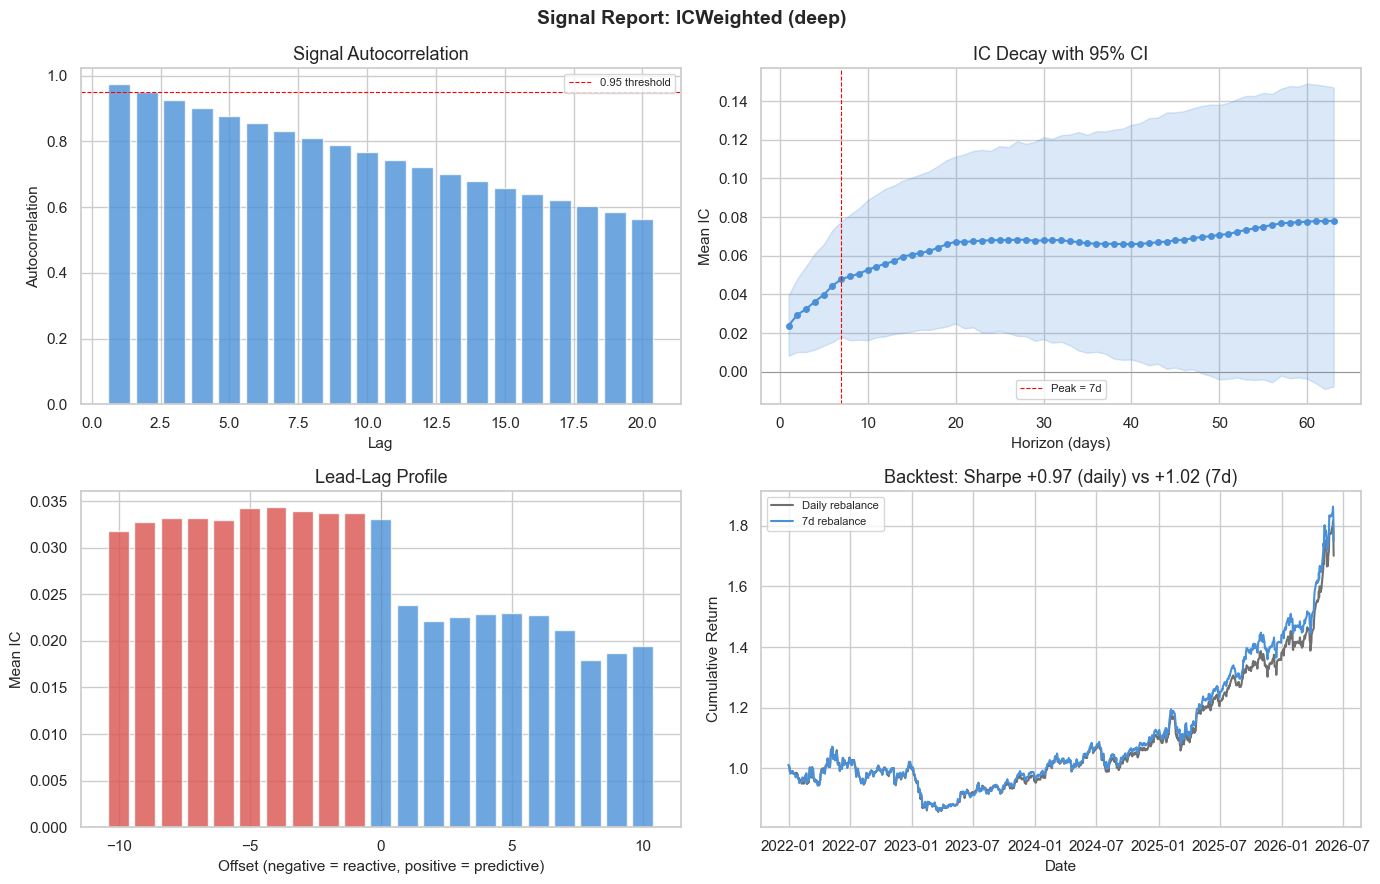

In [ ]:
# Same 63-day deep scan (deep_cfg from 4.3a) applied to the ICWeighted combiner.
icw_sig = combined["ICWeighted"].loc[common_start:]
icw_deep = SignalReport(icw_sig, closes_eval, name="ICWeighted (deep)", config=deep_cfg).run()
icw_deep.print_summary()
_ = icw_deep.plot()

> **Observations.**
> - **ICWeighted is the *fast* signal: a strong, flat edge that fades at long horizons.** Its HAC t-stat is ~2.9 and essentially constant from 1d to 21d (strongest at **1d, 2.96**), then decays — 42d 2.03, 63d **1.97 with a CI that straddles zero**. On the decay plot the IC rises and flattens around 20d while the CI band's lower edge lifts to a maximum (~+0.02) at ~20d and then collapses to zero just before 50d. The edge lives in the **1–42 day** range, not beyond.
> - **`natural_freq` lands at 7d, where it earns Sharpe 1.02** — reliability is front-loaded, so the picker chooses a fast cadence.
> - **Reliability peaks around 21d here too** (21d t_NW 2.94, the widest CI gap from zero), but the front-loaded profile and 7d natural frequency show the edge is already strong at fast cadences.
> - **Diagnostics.** Lag-1 autocorrelation 0.974 (quasi-static), turnover 0.13, and cross-sectional dispersion **0.816 — by far the largest of any signal here**. This is a pure *scale* artifact in the opposite direction to the Lasso: ICWeighted emits a weighted sum of unit-variance z-scored factors (values on an O(1) scale), versus the Lasso's ~1e-3 standardized coefficients. It carries no performance meaning — the IC is rank-based and the backtester scale-invariant — so the ~30× dispersion gap between the two combiners is units, not edge.
> - **Same reactive lean.** Lead-lag is reactive-dominant (~+0.033 past-return side vs ~+0.020 predictive), so as with the Lasso much of the IC is persistence; these full-sample figures sit on a bull-dominated window.


#### 4.3c Rebalance-frequency sweep

Both combiners are frozen at a 21-day rebalance, but their natural frequencies differ (Lasso ~20d, ICWeighted ~7d). Sweep the rebalance cadence for each across short-to-monthly horizons, split by regime, to see whether a faster or slower rebalance than 21d serves either signal — and in particular whether a faster cadence helps the bear.


In [ ]:
# Rebalance-frequency sweep for both combiners across short-to-monthly cadences,
# with the bear/bull split. Regime dates are inlined here for a self-contained test.
sweep_regimes = {"bear": ("2021-12-31", "2022-12-31"), "bull": ("2023-01-01", "2026-12-31")}
freqs = [1, 5, 7, 10, 15, 21, 31]

rows = []
for name in ["Lasso", "ICWeighted"]:
    sig = combined[name].loc[common_start:]
    for f in freqs:
        ret = VectorizedBacktester(cost_bps=10.0, rebalance_freq=f).run(closes_eval, sig)
        row = {"signal": name, "freq": f, "Sharpe": round(summary(ret)["sharpe_ratio"], 2)}
        for tag, (lo, hi) in sweep_regimes.items():
            row[f"Sh_{tag}"] = round(summary(ret.loc[lo:hi])["sharpe_ratio"], 2)
        rows.append(row)

freq_sweep = pd.DataFrame(rows).set_index(["signal", "freq"])
freq_sweep

Sharpe  Sh_bear  Sh_bull
signal     freq                          
Lasso      1       0.98    -0.05     1.33
           5       1.01     0.00     1.34
           7       1.08     0.10     1.42
           10      1.00    -0.10     1.36
           15      0.88    -0.20     1.23
           21      0.89     0.13     1.15
           31      0.91     0.52     1.02
ICWeighted 1       0.97     0.10     1.27
           5       0.99     0.07     1.30
           7       1.02     0.13     1.33
           10      1.01    -0.01     1.35
           15      0.84    -0.16     1.18
           21      0.85     0.09     1.11
           31      0.96     0.53     1.10

> **Observations.**
> - **Full-sample Sharpe peaks at a *fast* 7-day rebalance for both combiners** (Lasso 1.08, ICWeighted 1.02), well above the 21d figures (0.89 / 0.85). The full sample is bull-dominated, and momentum's fast-decaying edge is best harvested by frequent rebalancing.
> - **The bear prefers the opposite — a *slow* 31-day rebalance** (Sh_bear 0.52 / 0.53 at 31d, versus ~0.10 at 7d and negative around 15d). A choppy, mean-reverting bear whipsaws a fast book; rebalancing slowly holds the defensive LowVol tilt through the chop, so the combination's bear protection lives at the slow end.
> - **The two objectives pull apart by regime, and 21d sits in the trough between them.** Bull rewards fast, bear rewards slow; 21d captures the best of neither (bear ~0.10). The horizon that maximises IC *reliability* is not the one that maximises backtest Sharpe in either regime — a clean instance of the IC-vs-Sharpe divergence.
> - **The cadence is therefore an objective choice:** peak return (7d) versus all-weather robustness (31d — best bear, at modest full-sample cost), not a statistical one. The downstream regime analysis uses 31d to preserve the bear hedge.


### 4.4 Regularization robustness (alpha sweep)

Sweep the Lasso penalty to check the chosen `alpha=0.001` sits on a stable plateau rather than a snooped peak. The sweep uses point estimates only (no bootstrap) for speed, and reports `live_dates` to guard against a flattering Sharpe computed off an over-penalized, near-dead signal.


In [ ]:
sweep_cfg_alpha = SignalReportConfig(n_bootstrap=0, ic_decay_max_lag=21)
alphas = [0.0005, 0.001, 0.005, 0.01, 0.05]

sweep_rows = []
for a in alphas:
    sig = LassoCombiner(alpha=a).combine(combo_inputs, closes).loc[common_start:]
    live = int(sig.notna().any(axis=1).sum())
    r = SignalReport(sig, closes_eval, name=f"Lasso alpha={a}", config=sweep_cfg_alpha).run().results
    ibh = r["ic_by_horizon"].set_index("horizon")
    sweep_rows.append({
        "alpha":       a,
        "live_dates":  live,
        "IC@1d":       round(ibh.loc[1, "mean"], 4),
        "IC@21d":      round(ibh.loc[21, "mean"], 4),
        "nat_freq":    r["natural_freq"],
        "Sharpe(1d)":  round(r["sharpe_daily"], 2),
        "Sharpe(nat)": round(r["sharpe_natural"], 2),
    })

sweep = pd.DataFrame(sweep_rows).set_index("alpha")
sweep

,live_dates,IC@1d,IC@21d,nat_freq,Sharpe(1d),Sharpe(nat)
alpha,,,,,,
0.0005,1111,0.0171,0.0672,21,0.98,0.90
0.0010,1111,0.0171,0.0672,21,0.98,0.89
0.0050,1111,0.0177,0.0651,21,0.96,0.79
0.0100,1111,0.0142,0.0583,21,0.70,0.55
0.0500,1111,-0.0191,-0.0048,16,0.09,-0.26


> **Observations.**
> - **The chosen `alpha=0.001` sits on a flat plateau, not a snooped peak.** Across `0.0005 → 0.005` the IC (≈0.017 at 1d, ≈0.065–0.067 at 21d) and Sharpe(1d) (0.96–0.98) are essentially constant — a tenfold change in the penalty barely moves the signal. The 0.001 default is mid-plateau, so the result does not hinge on a fragile parameter choice; overall stability is preserved.
> - **Beyond the plateau the signal degrades sharply.** By `0.01` Sharpe(nat) has fallen to 0.55, and by `0.05` the penalty has zeroed enough structure that *both* IC@1d (−0.019) and IC@21d (−0.005) flip negative and the book turns unprofitable (Sharpe(nat) −0.26). The cliff confirms the penalty is doing real variable selection — too much of it kills the signal outright.
> - **`live_dates` stays at 1111 throughout**, so none of these Sharpes are flattered by an over-penalized, near-empty signal computed off a shrunken sample — the high-alpha degradation is genuine signal loss, not a coverage artifact.


### 4.5 Frozen-signal tear sheets

The frozen rebalance horizon for the regime and robustness analysis is **`FREEZE_HORIZON` = 31 days** — the slow cadence where the combination's bear protection concentrates (per the rebalance sweep above). The tear sheets here, though, are rendered at the **7-day weekly cadence** that maximises full-sample Sharpe for both combiners (Lasso 1.08, ICWeighted 1.02), to show each at its return-maximising best. Both are benchmarked against SPY to confirm the dollar-neutral book is ~beta-0. The two horizons answer different questions: 7d maximises return on the bull-dominated full sample, 31d preserves the bear hedge used in the regime split.


#### 4.5a Lasso


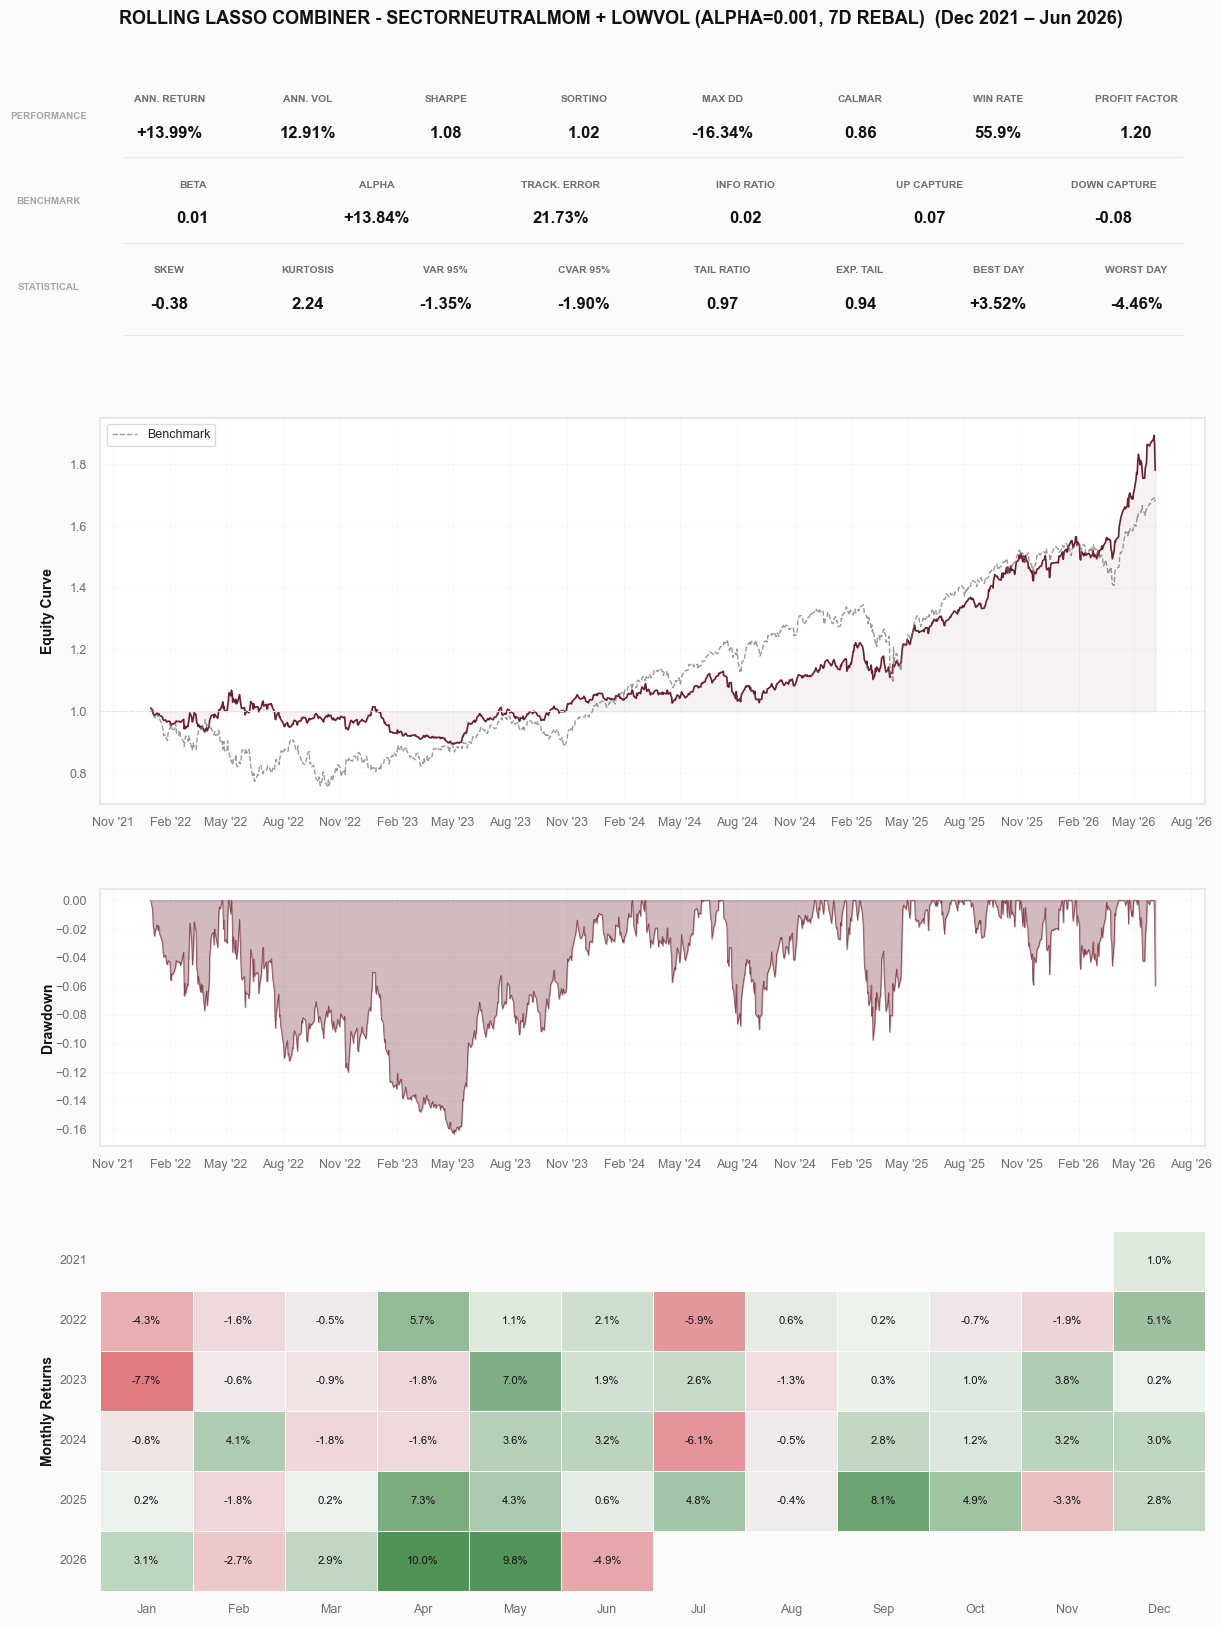

In [ ]:
# FREEZE_HORIZON (31d) is the cadence used by the regime/robustness analysis
# below, where the combination's bear protection concentrates. The tear sheets
# render at the 7-day weekly cadence that maximises full-sample Sharpe (sweep above).
FREEZE_HORIZON = 31
TEAR_HORIZON = 7

lasso_ret = VectorizedBacktester(cost_bps=10.0, rebalance_freq=TEAR_HORIZON).run(
    closes_eval, combined["Lasso"].loc[common_start:])
spy_ret = closes_all["SPY"].pct_change().reindex(lasso_ret.index)
plot_tearsheet(
    lasso_ret, benchmark_returns=spy_ret,
    title=f"Rolling Lasso Combiner - SectorNeutralMom + LowVol (alpha=0.001, {TEAR_HORIZON}d rebal)",
)

#### 4.5b ICWeighted


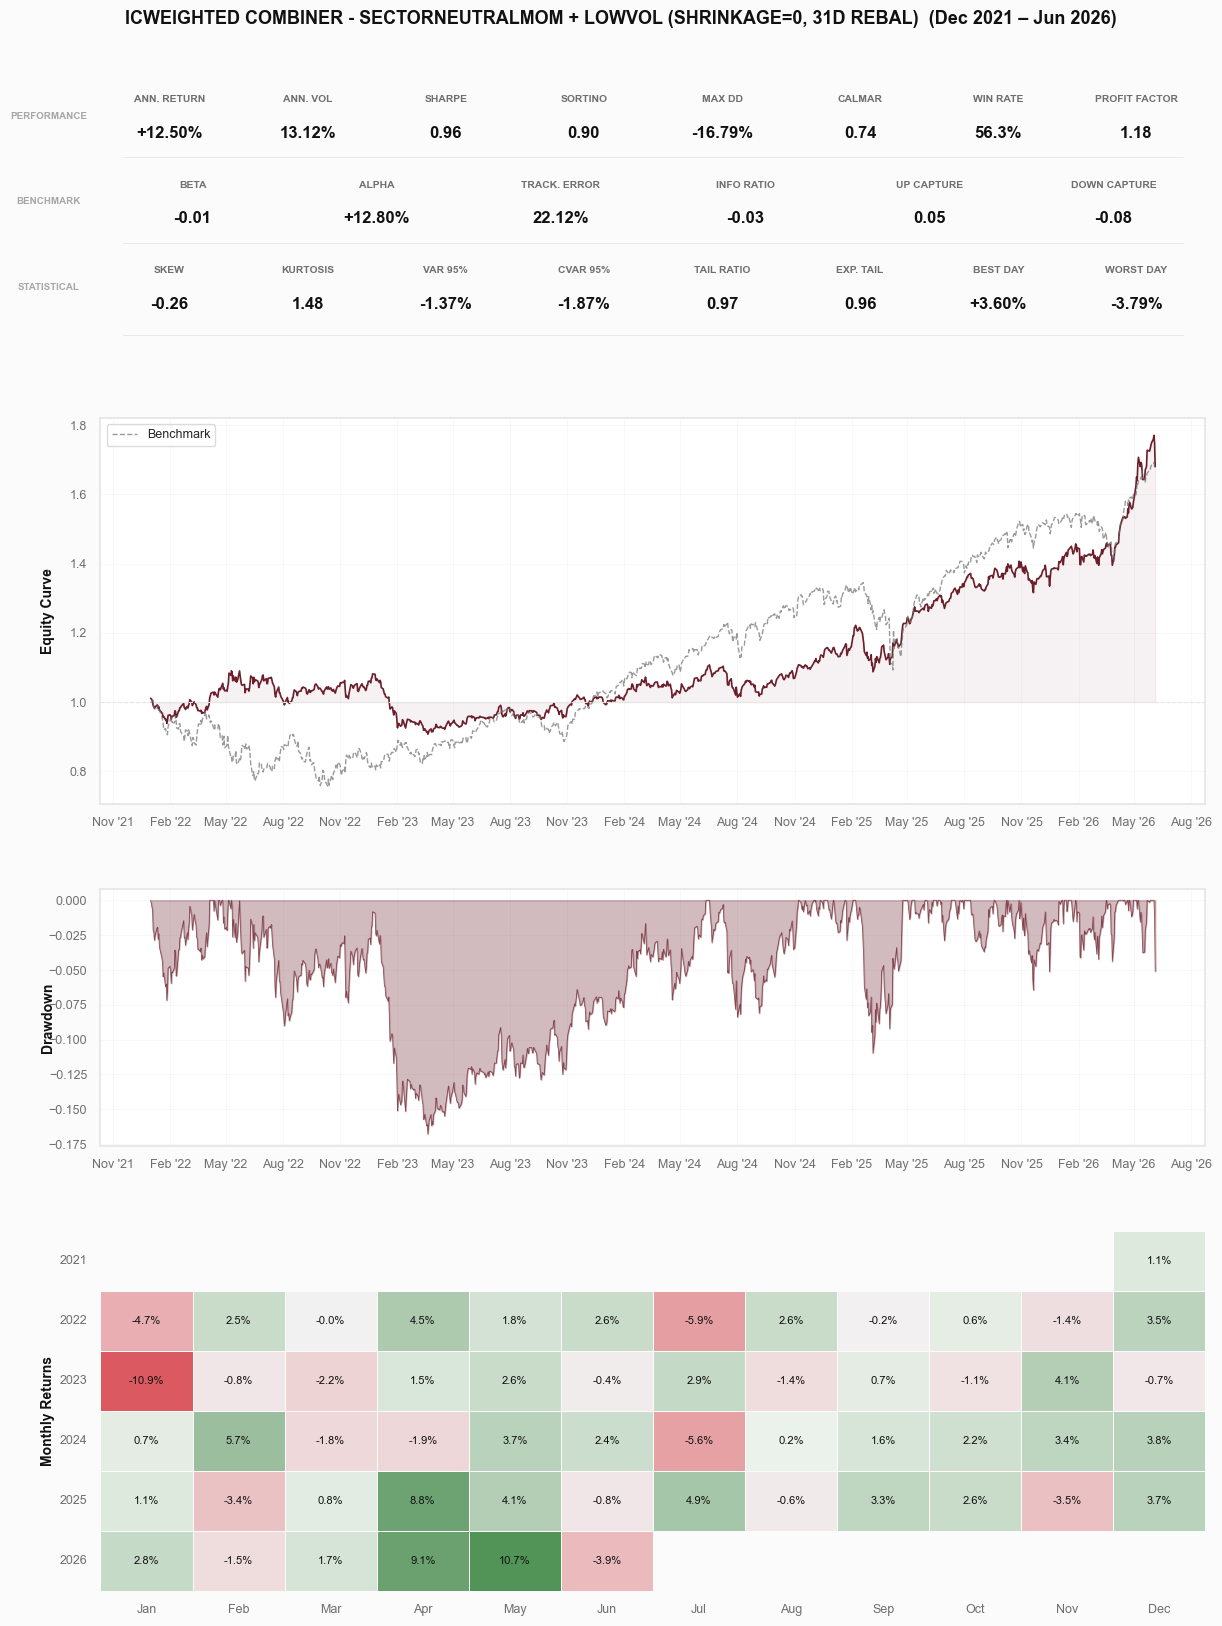

In [ ]:
# Same 7-day weekly cadence applied to the ICWeighted combiner.
icw_ret = VectorizedBacktester(cost_bps=10.0, rebalance_freq=TEAR_HORIZON).run(
    closes_eval, combined["ICWeighted"].loc[common_start:])
spy_ret = closes_all["SPY"].pct_change().reindex(icw_ret.index)
plot_tearsheet(
    icw_ret, benchmark_returns=spy_ret,
    title=f"ICWeighted Combiner - SectorNeutralMom + LowVol (shrinkage=0, {TEAR_HORIZON}d rebal)",
)

> **Observations.**
> - **Both combiners are market-neutral and near-twins at the 7-day cadence.** Lasso: Sharpe **1.08**, ann return 14.0%, beta to SPY **+0.007**, win rate 55.9%. ICWeighted: Sharpe **1.02**, ann return 13.6%, beta **−0.007**, win rate 55.8%. Essentially all return is alpha; the dollar-neutral books are confirmed ~beta-0, and their shared inputs make the profiles nearly identical.
> - **The damage concentrates at regime *transitions*, not within regimes.** The worst drawdowns (Lasso −16%, ICWeighted −20%) are taken not during the steady bear or bull but at the **bear→bull turn** — the sharp 2023 recovery off the low, where the stale momentum-and-defensive tilt reverses against the book (the classic momentum crash). The residual risk these signals still need to guard against is **transition volatility**, not either regime in isolation.
> - **Rebalance speed modulates this weakness.** At 7 days the book re-ranks fast, staying defensive throughout the bear and riding through the turn relatively smoothly. The slower 31-day cadence used for the regime analysis earns a much higher *in-bear* Sharpe (holding the defensive tilt through the choppy decline) but is **hit far harder at the transition**, when its stale positioning unwinds slowly into the rising market. Slower rebalancing buys peak in-regime performance at the cost of transition robustness — and ICWeighted's marginally heavier defensive tilt makes its drawdown the deeper of the two.


### 4.6 Regime stability

The headline stress test: split **both frozen combiners** into the 2022 bear and the 2023-26 bull to check whether the edge is cross-regime or carried by one.

The eval window starts 2021-12-31, so the bear leg is only ~1 year — about 8 independent 31-day windows — so its IC and Sharpe are noisy; read the **sign/direction** there, not the precise magnitude. The shared `full_and_regime` evaluator (defined in the next cell) backtests a signal at the frozen 31d cadence and reports full-sample IC/Sharpe plus the per-regime split, and is reused by the controls below.


In [ ]:
regimes = {
    "2022 bear":    ("2021-12-31", "2022-12-31"),
    "2023-26 bull": ("2023-01-01", "2026-12-31"),
}


def full_and_regime(sig):
    sig = sig.loc[common_start:]
    ret = VectorizedBacktester(cost_bps=10.0, rebalance_freq=FREEZE_HORIZON).run(closes_eval, sig)
    ic1 = compute_ic(sig, closes_eval.pct_change().shift(-1))
    ich = compute_ic(sig, closes_eval.pct_change(FREEZE_HORIZON).shift(-FREEZE_HORIZON))
    row = {"IC@1d": round(ic1.mean(), 4),
           f"IC@{FREEZE_HORIZON}d": round(ich.mean(), 4),
           "Sharpe": round(summary(ret)["sharpe_ratio"], 2)}
    for name, (lo, hi) in regimes.items():
        tag = "bear" if "bear" in name else "bull"
        row[f"Sh_{tag}"] = round(summary(ret.loc[lo:hi])["sharpe_ratio"], 2)
        row[f"IC{FREEZE_HORIZON}_{tag}"] = round(ich.loc[lo:hi].mean(), 4)
    return row

In [ ]:
spy_daily = closes_all["SPY"].pct_change()  # benchmark for the regime split
H = FREEZE_HORIZON

# Bear and bull partition the sample; the transition is an *overlapping* window
# bracketing the SPY low (12 Oct 2022) and the signals' drawdown troughs (Mar-Apr
# 2023), to isolate the bear->bull regime change where the book is whipsawed.
table_regimes = {
    "2022 bear":             ("2021-12-31", "2022-12-31"),
    "bear->bull transition": ("2022-09-30", "2023-04-30"),
    "2023-26 bull":          ("2023-01-01", "2026-12-31"),
}

rows = []
for sig_name in ["Lasso", "ICWeighted"]:
    sig = combined[sig_name].loc[common_start:]
    ret = VectorizedBacktester(cost_bps=10.0, rebalance_freq=H).run(closes_eval, sig)
    ic_1 = compute_ic(sig, closes_eval.pct_change().shift(-1))
    ic_h = compute_ic(sig, closes_eval.pct_change(H).shift(-H))
    for regime_name, (lo, hi) in table_regimes.items():
        r = ret.loc[lo:hi]
        st = summary(r)
        rows.append({
            "signal":     sig_name,
            "regime":     regime_name,
            "days":       len(r),
            "IC@1d":      round(ic_1.loc[lo:hi].mean(), 4),
            f"IC@{H}d":   round(ic_h.loc[lo:hi].mean(), 4),
            "Sharpe":     round(st["sharpe_ratio"], 2),
            "AnnRet":     round(st["annualized_return"], 3),
            "MaxDD":      round(st["max_drawdown"], 3),
            "SPY AnnRet": round(summary(spy_daily.loc[lo:hi].dropna())["annualized_return"], 3),
        })

regime_tbl = pd.DataFrame(rows).set_index(["signal", "regime"])
regime_tbl

days   IC@1d  IC@31d  Sharpe  AnnRet  MaxDD  \
signal     regime                                                               
Lasso      2022 bear               252  0.0124  0.0063    0.52   0.062 -0.089   
           bear->bull transition   145 -0.0314 -0.1025   -1.70  -0.166 -0.143   
           2023-26 bull            858  0.0185  0.0928    1.02   0.130 -0.134   
ICWeighted 2022 bear               252  0.0170  0.0073    0.53   0.067 -0.090   
           bear->bull transition   145 -0.0086 -0.1103   -1.39  -0.168 -0.161   
           2023-26 bull            858  0.0259  0.0865    1.10   0.143 -0.150   

                                  SPY AnnRet  
signal     regime                             
Lasso      2022 bear                  -0.184  
           bear->bull transition       0.287  
           2023-26 bull                0.228  
ICWeighted 2022 bear                  -0.184  
           bear->bull transition       0.287  
           2023-26 bull                0.228

> **Observations.**
> - **Both combiners are positive in both the bear and the bull.** At the frozen 31-day cadence the Lasso earns Sharpe **0.52 (bear) / 1.02 (bull)** and ICWeighted **0.53 / 1.10**, each with a *positive* annualized return in the 2022 bear (+6.2% / +6.7%) while SPY fell **−18.4%**. The book is dollar-neutral (beta ~0), so that bear profit is the low-vol-minus-high-vol spread paying off, not market exposure.
> - **The damage is concentrated in the regime *change*, not the regimes.** Over the bear-bull transition window (late Sep 2022 – Apr 2023, bracketing the SPY low of 12 Oct 2022 and both signals' drawdown troughs in Mar–Apr 2023), Sharpe is sharply **negative: −1.70 (Lasso), −1.39 (ICWeighted)**, and this overlapping window is where each book takes its full-sample max drawdown (~−16%). The signals are profitable *within* each regime but get whipsawed as the regime turns, when the stale momentum-and-defensive tilt reverses against a violently recovering market — the momentum crash.
> - **The bear is real but weakly evidenced.** Sharpe ~0.52 over a single ~1-year window is only a ~0.5 t-stat, and bear IC@31d is a marginal +0.006–0.007. So the bear contribution is mostly the **defensive tilt being directionally right** (low-vol outperformed through the 2022 decline), not fine-grained cross-sectional selection, which stays noisy inside the bear. The bull is where the cross-sectional alpha concentrates (IC@31d +0.09, Sharpe ~1.0–1.1).
> - **ICWeighted edges the Lasso across the board at this cadence** — bear 0.53 vs 0.52, bull 1.10 vs 1.02, and a shallower transition (−1.39 vs −1.70) — consistent with its full-sample lead, though it carries a slightly deeper bull drawdown (−15.0% vs −13.4%).


**Decomposition: where does the all-weather profile come from, and where does it break?** Lay the two raw legs (SectorNeutralMom, LowVol) beside the two combiners at the frozen 31d cadence, split across the bear, the bear-bull transition, and the bull. This shows whether the cross-regime robustness is intrinsic to momentum or supplied by the defensive LowVol leg — and how each piece behaves through the regime change.


In [ ]:
decomp_regimes = {
    "bear":  ("2021-12-31", "2022-12-31"),
    "trans": ("2022-09-30", "2023-04-30"),   # bear->bull transition (overlaps bear/bull)
    "bull":  ("2023-01-01", "2026-12-31"),
}

def regime_breakdown(sig):
    sig = sig.loc[common_start:]
    ret = VectorizedBacktester(cost_bps=10.0, rebalance_freq=FREEZE_HORIZON).run(closes_eval, sig)
    ich = compute_ic(sig, closes_eval.pct_change(FREEZE_HORIZON).shift(-FREEZE_HORIZON))
    row = {"Sharpe": round(summary(ret)["sharpe_ratio"], 2)}
    for tag, (lo, hi) in decomp_regimes.items():
        row[f"Sh_{tag}"] = round(summary(ret.loc[lo:hi])["sharpe_ratio"], 2)
    row["IC@31d"] = round(ich.mean(), 4)
    for tag, (lo, hi) in decomp_regimes.items():
        row[f"IC_{tag}"] = round(ich.loc[lo:hi].mean(), 4)
    return row

decomp = pd.DataFrame({
    "SectorNeutralMom": regime_breakdown(signals["SectorNeutralMom"]),
    "LowVol":           regime_breakdown(signals["LowVol"]),
    "ICWeighted":       regime_breakdown(combined["ICWeighted"]),
    "Lasso":            regime_breakdown(combined["Lasso"]),
}).T
decomp

,Sharpe,Sh_bear,Sh_trans,Sh_bull,IC@31d,IC_bear,IC_trans,IC_bull
SectorNeutralMom,0.87,-0.73,-1.37,1.18,0.0267,-0.0414,-0.0708,0.0475
LowVol,-0.97,1.00,-1.45,-1.71,-0.0712,0.0787,-0.1482,-0.1168
ICWeighted,0.96,0.53,-1.39,1.10,0.0681,0.0073,-0.1103,0.0865
Lasso,0.91,0.52,-1.70,1.02,0.0726,0.0063,-0.1025,0.0928


> **Observations.**
> - **The two raw legs are regime mirror images — a momentum/defensive barbell.** SectorNeutralMomentum is the bull engine (bull +1.18, bear −0.73); LowVol, as-built, is the bear engine (bear **+1.00**, bull −1.71), and it carries the strongest single-factor bear IC@31d in the study (**+0.079**). They win in opposite regimes, which is precisely why blending them works.
> - **The combiners fuse the two into an all-weather signal — but the bear edge is *diluted*.** ICWeighted and Lasso inherit momentum's bull (1.10 / 1.02) and LowVol's bear (0.53 / 0.52), landing positive in both stable regimes. Yet their bear IC@31d (+0.006 / +0.007) is far weaker than LowVol's raw +0.079: momentum's negative bear IC (−0.041) partly cancels the defensive leg, so the defensive factor does the bear work while momentum drags on it.
> - **The transition defeats *every* row — the structural weakness.** Through the bear→bull turn all four signals are sharply negative (Sh −1.37 to −1.70; IC@31d −0.07 to −0.15), including raw LowVol (−1.45). The momentum/defensive anticorrelation that makes the blend all-weather in the *stable* regimes **collapses at the turn**: momentum is still short the recovering losers *and* LowVol is still long the lagging defensives, so both legs lose together. No static blend of these two can protect the transition — guarding it would need a third, volatility/transition-aware element.


**Why both legs fail at the turn — the trailing-orientation lag.** The sign-aware combiners orient each factor by its 252-day *trailing* IC, so the orientation lags the regime. Track LowVol's trailing-252 IC (the sign the combiner sets) against the realized ~1-month IC (what the market actually rewarded) through the transition: where the trailing sign is stuck on the regime that just ended while the realized IC has already flipped, the book is on the wrong side.


In [ ]:
# LowVol orientation lag: the combiner's trailing-252 IC (its long/short sign)
# vs the realized ~1-month IC (what actually paid), probed through the transition.
ic_lv = compute_ic(signals["LowVol"], closes.pct_change().shift(-1))  # daily IC, as-built
orientation = ic_lv.rolling(252).mean().shift(1)   # trailing-252: the combiner's sign
realized = ic_lv.rolling(21).mean()                # realized ~1-month IC

rows = []
for d in ["2022-08-31", "2022-12-30", "2023-02-28", "2023-04-28", "2023-06-30"]:
    dt = closes.index[closes.index.get_indexer(
        [pd.Timestamp(d, tz=closes.index.tz)], method="nearest")[0]]
    o, r = orientation.loc[dt], realized.loc[dt]
    rows.append({
        "date":                      dt.date(),
        "trailing252 (orientation)": round(o, 4),
        "realized21":                round(r, 4),
        "combiner tilt":             "long low-vol" if o > 0 else "long high-vol",
        "rewarded":                  "low-vol" if r > 0 else "high-vol",
    })

lowvol_orientation = pd.DataFrame(rows).set_index("date")
lowvol_orientation

,trailing252 (orientation),realized21,combiner tilt,rewarded
date,,,,
2022-08-31,0.0233,0.0765,long low-vol,low-vol
2022-12-30,0.0358,0.0763,long low-vol,low-vol
2023-02-28,0.0085,-0.0077,long low-vol,high-vol
2023-04-28,-0.0031,0.0610,long high-vol,low-vol
2023-06-30,-0.0145,-0.0324,long high-vol,high-vol


> **Observations.**
> - **The combiner's LowVol orientation lags the regime.** It orients by the 252-day *trailing* IC, which stays **positive (long low-vol) from the bear through ~April 2023**. The realized IC, meanwhile, whipsaws through the recovery — low-vol still winning into Dec 2022 (+0.08), high-vol by Feb 2023 (−0.01), low-vol again by Apr (+0.06).
> - **So the book is caught on the wrong side twice:** long low-vol when high-vol bounces (Feb 2023), then flipping to long high-vol just as low-vol recovers (Apr 2023). The transition is both where the orientation is most stale (the regime just flipped) and where the cross-sectional vol payoff is least stable, so a lookback-fit sign is repeatedly wrong. This is a **non-stationarity / lookback** problem.

### 4.7 Robustness controls

Two controls: does the curated 2-factor pick matter (kitchen sink), and where does the regime alpha actually live (momentum vs defensive barbell)?

#### 4.7.1 Kitchen-sink: all factors

Run all three combiners on the full factor set to test whether curation helped and whether the bull-only pattern belongs to the factor set rather than the 2-factor choice. Two factors are excluded: **XSMomentum** (a perfect rank-duplicate of Momentum, which makes the Lasso coefficients unidentifiable) and **ResidualMom** (its late 2021 start would push the common window past the 2022 bear and gut that regime's sample). That leaves 11 factors on the same 2021-12-31 window.


In [ ]:
all_inputs = {k: v for k, v in signals.items()
              if k not in ("XSMomentum", "ResidualMom")}
print(f"Kitchen-sink inputs ({len(all_inputs)}): {list(all_inputs)}")

combined_all = {
    "EqualWeight_all": EqualWeightCombiner().combine(all_inputs),
    "ICWeighted_all":  ICWeightedCombiner(shrinkage=0.0).combine(all_inputs, closes),
    "Lasso_all":       LassoCombiner(alpha=0.001).combine(all_inputs, closes),
}

ctrl = pd.DataFrame({n: full_and_regime(s) for n, s in combined_all.items()}).T
ctrl

Kitchen-sink inputs (11): ['Momentum', 'RSI', 'Bollinger', 'STReversal', 'LowVol', 'SectorNeutralMom', 'Quality', 'RollingSharpe', 'RollingCVaR', 'RollingMaxDD', 'RollingSkew']


,IC@1d,IC@31d,Sharpe,Sh_bear,IC31_bear,Sh_bull,IC31_bull
EqualWeight_all,0.0083,-0.0188,-0.44,1.18,0.0336,-1.10,-0.0348
ICWeighted_all,0.0218,0.0419,0.69,-0.06,-0.0304,0.91,0.0639
Lasso_all,0.0120,0.0619,0.77,-0.10,0.0240,1.03,0.0734


> **Observations.**
> - **Curation helps — the focused pair beats the kitchen sink, especially in the bear.** The curated momentum+LowVol combiners are all-weather (bear Sharpe +0.52 / +0.53, full 0.91 / 0.96), but feeding all eleven factors to the same combiners is **worse on both counts**: Lasso_all full Sharpe 0.77 with bear **−0.10**, ICWeighted_all 0.69 with bear **−0.06**. The kitchen-sink combiners are bull-conditional (bull 1.03 / 0.91, bear negative); diluting the clean momentum/defensive barbell among nine extra factors *loses the bear protection*. The deliberate two-factor pairing is what delivers the all-weather profile — all-weather is not automatic from the wider factor set.
> - **A marginally positive bear IC that doesn't pay.** Lasso_all shows bear IC@31d +0.024 yet a *negative* bear Sharpe (−0.10): a small, noisy positive rank-correlation on ~8 independent windows that doesn't translate into a profitable, magnitude-sized book — the rank-vs-magnitude gap on thin data.


**Attribution — which sub-groups drive the EqualWeight inversion?**

EqualWeight_all flips into a net-defensive book (negative full Sharpe, positive bear, negative bull). To attribute it, equal-weight each *as-built* factor sub-group — momentum, reversal, risk — on its own and regime-split. This separates whether the inversion comes from the risk factors, the reversal factors, or both. The **All (11)** row reproduces the EqualWeight_all line from the table above as a cross-check.

In [82]:
# Equal-weight each as-built sub-group on its own and regime-split, reusing the
# §4.6 full_and_regime evaluator (31d cadence, no sign flip). The "All (11)" row
# matches EqualWeight_all from the kitchen-sink table above as a cross-check.
subgroups = {
    "Momentum (3)": ["Momentum", "SectorNeutralMom", "RollingSharpe"],
    "Reversal (3)": ["RSI", "Bollinger", "STReversal"],
    "Risk (4)":     ["LowVol", "RollingCVaR", "RollingMaxDD", "RollingSkew"],
    "All (11)":     [k for k in signals if k not in ("XSMomentum", "ResidualMom")],
}

attribution = pd.DataFrame({
    name: full_and_regime(EqualWeightCombiner().combine({k: signals[k] for k in members}))
    for name, members in subgroups.items()
}).T
attribution

,IC@1d,IC@31d,Sharpe,Sh_bear,IC31_bear,Sh_bull,IC31_bull
Momentum (3),0.0243,0.0357,0.77,-0.08,-0.0193,0.98,0.0524
Reversal (3),-0.0007,-0.0047,0.05,1.62,0.0318,-0.43,-0.0159
Risk (4),-0.0097,-0.0614,-0.92,1.08,0.0860,-1.68,-0.1062
All (11),0.0083,-0.0188,-0.44,1.18,0.0336,-1.10,-0.0348


> **Observations.**
> - **EqualWeight_all inverts into a bear hedge — driven by two groups, not one.** Blindly averaging all eleven raw factors gives a negative full Sharpe (−0.44) but a strongly positive bear Sharpe (+1.18) and negative bull (−1.10). Sub-group attribution (equal-weight each as-built) shows the **risk factors** supply the bull underperformance and the negative full-sample number (Risk-only Sharpe −0.92, bull −1.68), while the **reversal factors** supply most of the bear outperformance (Reversal-only bear +1.62, full-sample dead at +0.05).
> - **The mechanism:** the 2022 decline was a short, *choppy* drawdown with sharp bear rallies — a reversal regime where short-horizon return autocorrelation turns negative. Slow 252-day momentum is on the wrong side of that flipped sign and cannot re-rank fast enough, while the short-window contrarian factors harvest exactly the mean reversion. Because equal-weight can't flip anything, it nets out defensive/contrarian — the bear hedge the sign-aware combiners can't build.


#### 4.7.2 Momentum / defensive / reversal barbell

Split the universe into momentum-only, defensive-only, and reversal-only equal-weight books and split each across the bear, the bear→bull transition, and the bull, to see which factor family carries each regime — and whether any family covers the transition that the momentum/defensive pair cannot.


In [ ]:
mom_only = {k: signals[k] for k in ["Momentum", "SectorNeutralMom", "RollingSharpe"]}
def_only = {k: signals[k] for k in ["LowVol", "RollingCVaR", "RollingMaxDD", "Quality"]}
rev_only = {k: signals[k] for k in ["RSI", "Bollinger", "STReversal"]}

# regime_breakdown (bear / transition / bull) is defined in the decomposition (4.6).
barbell = pd.DataFrame({
    "Momentum-only (EW)":            regime_breakdown(EqualWeightCombiner().combine(mom_only)),
    "Defensive-only (EW, as-built)": regime_breakdown(EqualWeightCombiner().combine(def_only)),
    "Reversal-only (EW, as-built)":  regime_breakdown(EqualWeightCombiner().combine(rev_only)),
}).T
barbell

,Sharpe,Sh_bear,Sh_trans,Sh_bull,IC@31d,IC_bear,IC_trans,IC_bull
Momentum-only (EW),0.77,-0.08,-1.23,0.98,0.0357,-0.0193,-0.1102,0.0524
"Defensive-only (EW, as-built)",-0.97,0.86,-1.42,-1.74,-0.0683,0.0450,-0.1671,-0.1028
"Reversal-only (EW, as-built)",0.05,1.62,2.23,-0.43,-0.0047,0.0318,0.0435,-0.0159


> **Observations.**
> - **Three families, three regimes — each regime has its own engine.** Momentum is the bull engine (bull +0.98, bear −0.08); the as-built defensives are the bear engine (bear +0.86, bull −1.74); and — the key result — the **reversal family is the *transition* engine** (transition Sharpe **+2.23**, IC@31d **+0.044**), while flat-to-negative elsewhere (bull −0.43, full-sample 0.05). The choppy bear→bull recovery, where beaten-down names violently bounce, is exactly what short-term reversal is built to harvest.
> - **This identifies the missing piece.** The momentum+defensive barbell covers the bull and the bear but **both legs lose in the transition** (−1.23 / −1.42); reversal is the only family that *profits* there (+2.23). A regime-complete signal would pair all three — momentum for the bull, defensives for the bear, reversal for the turn.
> - **But reversal cannot be added statically.** It is full-sample dead (Sharpe 0.05) and bull-negative, so a static or trailing-IC combiner — which orients factors on full-sample / trailing data — would size it toward zero or flip it the wrong way outside the transition, adding noise rather than protection. Capturing the transition engine needs **regime-conditional orientation**: turn reversal on, correctly signed, only through the turn. The same lookback problem that wrong-foots momentum and LowVol at the transition is why reversal can't simply be blended in.


#### 4.7.3 Can the transition engine be added statically?

Reversal is the transition engine standalone (§4.7.2, Sharpe +2.23 there). Does feeding it into the frozen combiner capture that transition alpha, or does a static blend fail to target it? Use the **reversal family, equal-weighted** (RSI + Bollinger + STReversal) as a single input, and test three pairings per combiner — the frozen SNM + LowVol, that pair plus reversal, and momentum + reversal alone — split by regime. If the static blend can harness reversal, the transition column should lift.


In [ ]:
reversal = EqualWeightCombiner().combine(
    {k: signals[k] for k in ["RSI", "Bollinger", "STReversal"]})

pair    = {"SectorNeutralMom": signals["SectorNeutralMom"], "LowVol": signals["LowVol"]}
trio    = {**pair, "Reversal": reversal}
mom_rev = {"SectorNeutralMom": signals["SectorNeutralMom"], "Reversal": reversal}

rows = {}
for cname, comb in [("Lasso", LassoCombiner(alpha=0.001)),
                    ("ICWeighted", ICWeightedCombiner(shrinkage=0.0))]:
    for label, inputs in [("SNM+LowVol", pair),
                          ("SNM+LowVol+Reversal", trio),
                          ("SNM+Reversal", mom_rev)]:
        rows[f"{cname}: {label}"] = regime_breakdown(comb.combine(inputs, closes))

reversal_test = pd.DataFrame(rows).T
reversal_test

,Sharpe,Sh_bear,Sh_trans,Sh_bull,IC@31d,IC_bear,IC_trans,IC_bull
Lasso: SNM+LowVol,0.91,0.52,-1.70,1.02,0.0726,0.0063,-0.1025,0.0928
Lasso: SNM+LowVol+Reversal,0.74,-0.27,-1.80,1.03,0.0654,-0.0125,-0.0964,0.0891
Lasso: SNM+Reversal,0.27,-2.13,-2.74,0.79,0.0174,-0.0398,-0.0114,0.0349
ICWeighted: SNM+LowVol,0.96,0.53,-1.39,1.10,0.0681,0.0073,-0.1103,0.0865
ICWeighted: SNM+LowVol+Reversal,0.77,-0.39,-1.64,1.11,0.0599,-0.0148,-0.1300,0.0826
ICWeighted: SNM+Reversal,0.35,-1.79,-2.24,0.86,0.0174,-0.0672,-0.0886,0.0432


> **Observations.**
> - **Reversal's standalone transition edge (+2.23, §4.7.2) is never preserved in any combo.** Every pairing is strongly negative through the turn — SNM+LowVol+Reversal −1.80 / −1.64, and SNM+Reversal −2.74 / −2.24 (worse than the frozen pair's −1.70 / −1.39). Adding the reversal family does not rescue the transition for either combiner.
> - **It actively degrades the proven pair.** SNM+LowVol+Reversal drops full Sharpe (0.91 → 0.74, 0.96 → 0.77) and collapses the bear (0.52 → −0.27, 0.53 → −0.39) — the equal-weight family hurts more than a single reversal factor would, because it loads more fast, full-sample-dead signal into a book the combiner cannot orient. Dropping the defensive leg entirely (SNM+Reversal) is worse still: no bear protection (−2.1 / −1.8) and the deepest transition loss.
> - **Yet reversal *does* carry transition information.** The cross-sectional *ranking* improves markedly when reversal is added: SNM+Reversal's transition IC@31d is **−0.011**, far less negative than the pair's −0.103. The edge is there in the ranks; it dies in the *sizing*. This is the slow-factor dilution at work — reversal is a small, fast, full-sample-dead component that the combiner weights down, while the quasi-static momentum and LowVol legs dominate the magnitude-weighted positions; at the turn those slow legs are maximally wrong (both crashing), so their large tilts swamp reversal's small correct one. The fast edge cannot survive being averaged with two slow factors that are themselves wrong-footed.
> - **This reinforces the structural fix.** Reversal's transition value is real but lives at a different timescale and a different (regime-specific) orientation than the bull/bear engines. A single static weight vector — sized by full-sample fit and dominated by the persistent legs — cannot express it. Only regime-conditional orientation (reversal on and correctly signed *only* at the turn, slow legs down-weighted there) can capture it.


### 4.8 IC-weighting diagnostics

ICWeighted is the stronger of the two combiners, and it leans entirely on trailing IC — so what does trailing-IC weighting actually buy? Two diagnostics: whether a factor's trailing IC predicts its future IC at all (§4.8.1), and whether decaying the IC window faster — to react sooner to a regime change — helps (§4.8.2).


#### 4.8.1 IC autocorrelation

IC-weighting bets that a factor's trailing IC carries information about its future IC. Test that directly via the autocorrelation of each factor's daily IC series — separating whether trailing IC predicts the *magnitude* of future IC (timing) from whether it merely supplies a stable *sign* (orientation).


In [ ]:
fwd_1d = closes_eval.pct_change().shift(-1)
ic_lags = [1, 5, 21, 63]

rows = []
for name, sig in signals.items():
    ic = compute_ic(sig.loc[common_start:], fwd_1d).dropna()
    row = {"factor": name, "mean_IC": round(ic.mean(), 4), "IC_vol": round(ic.std(), 3)}
    for L in ic_lags:
        row[f"acf_{L}"] = round(ic.autocorr(lag=L), 3)
    rows.append(row)

ic_acf = pd.DataFrame(rows).set_index("factor")
ic_acf

,mean_IC,IC_vol,acf_1,acf_5,acf_21,acf_63
factor,,,,,,
Momentum,0.0261,0.277,0.005,-0.040,-0.013,0.039
XSMomentum,0.0261,0.277,0.005,-0.040,-0.013,0.039
RSI,-0.0019,0.227,0.019,0.093,-0.035,-0.001
Bollinger,-0.0017,0.226,0.043,0.089,-0.005,-0.013
STReversal,0.0017,0.243,-0.040,0.034,-0.014,-0.026
LowVol,-0.0119,0.293,0.023,0.004,-0.013,0.070
ResidualMom,0.0230,0.238,-0.011,-0.058,-0.005,0.033
SectorNeutralMom,0.0203,0.199,0.003,-0.047,-0.042,0.049
Quality,-0.0028,0.154,0.031,0.006,-0.012,0.038


> **Observations.**
> - **Daily IC has essentially no autocorrelation.** Across all 13 factors and lags 1/5/21/63, the IC autocorrelations sit between −0.064 and +0.093, against a ±1.96/√1110 ≈ **±0.059** noise band. Almost every value is inside it; the few that peek outside (RSI/Bollinger acf_5 ≈ 0.09) are isolated and consistent with chance. **Trailing IC does not predict the *magnitude* of next-period IC** — there is no short-term factor-quality signal to time.
> - **But IC-weighting is not useless — its value is the *sign*, not the timing.** ICWeighted is the stronger combiner precisely because it uses the trailing-IC *sign* to orient each factor to its profitable direction — flipping LowVol from its as-built negative IC into the bear-protective long-defensive book. That sign is stable at the regime scale (the mean-IC column: momentum reliably positive, ~+0.02 to +0.03; LowVol/CVaR reliably negative) even though the day-to-day IC is pure noise. Orientation, not adaptive quality-weighting, is what trailing IC delivers — and it is enough to build the all-weather blend.
> - **The same result explains the transition lag.** Because there is no short-term IC persistence, the orientation can only update at the slow trailing-window pace; it cannot detect and react to a regime flip quickly. The very absence of fast IC signal that makes day-to-day timing futile is also why the sign-orientation goes stale at the turn — the engine that gives the right slow orientation in stable regimes is structurally blind to fast regime changes.
> - **Equal-weight is therefore *not* the safe default here.** It cannot flip a negative-IC factor at all, so it cannot build the orientation that makes the combination all-weather (it fails outright in §4.2). The real choice is not "IC-weighting vs a robust equal-weight baseline" but between two *sign-aware* orientations — signed IC-weighting and the Lasso's signed coefficients — both of which beat blind averaging.


#### 4.8.2 EWM vs flat IC-weighting

§4.8.1 showed the sign-orientation lags because trailing IC has no short-term persistence. Does decaying the IC window faster (EWM) let the orientation react sooner to a regime change — and does it help the reversal-inclusive set, where the fast transition engine might benefit from faster weighting? Test flat-252 against EWM at several halflives, on the frozen pair and the pair-plus-reversal, split by regime (bear / transition / bull) with final PnL.


In [ ]:
rev_fam = EqualWeightCombiner().combine(
    {k: signals[k] for k in ["RSI", "Bollinger", "STReversal"]})

ic_inputs = {
    "SNM+LowVol":          {"SectorNeutralMom": signals["SectorNeutralMom"],
                            "LowVol": signals["LowVol"]},
    "SNM+LowVol+Reversal": {"SectorNeutralMom": signals["SectorNeutralMom"],
                            "LowVol": signals["LowVol"], "Reversal": rev_fam},
}
ic_variants = {
    "flat-252":  dict(use_ewm=False, lookback=252),
    "ewm-hl63":  dict(use_ewm=True, halflife=63),
    "ewm-hl126": dict(use_ewm=True, halflife=126),
    "ewm-hl252": dict(use_ewm=True, halflife=252),
}

def regime_pnl(sig):
    sig = sig.loc[common_start:]
    ret = VectorizedBacktester(cost_bps=10.0, rebalance_freq=FREEZE_HORIZON).run(closes_eval, sig)
    row = {"Sharpe": round(summary(ret)["sharpe_ratio"], 2)}
    for tag, (lo, hi) in decomp_regimes.items():   # bear / trans / bull (from 4.6)
        row[f"Sh_{tag}"] = round(summary(ret.loc[lo:hi])["sharpe_ratio"], 2)
    row["PnL"] = round((1 + ret).prod() - 1, 3)
    return row

rows = {}
for iname, inputs in ic_inputs.items():
    for vname, cfg in ic_variants.items():
        rows[f"{iname} | {vname}"] = regime_pnl(
            ICWeightedCombiner(shrinkage=0.0, **cfg).combine(inputs, closes))

ewm_tbl = pd.DataFrame(rows).T
ewm_tbl

,Sharpe,Sh_bear,Sh_trans,Sh_bull,PnL
SNM+LowVol | flat-252,0.96,0.53,-1.39,1.10,0.680
SNM+LowVol | ewm-hl63,0.92,0.57,-1.10,1.04,0.648
SNM+LowVol | ewm-hl126,0.99,0.89,-1.01,1.03,0.726
SNM+LowVol | ewm-hl252,0.93,0.92,-1.44,0.93,0.654
SNM+LowVol+Reversal | flat-252,0.77,-0.39,-1.64,1.11,0.449
SNM+LowVol+Reversal | ewm-hl63,0.84,0.11,-1.39,1.08,0.531
SNM+LowVol+Reversal | ewm-hl126,0.84,0.23,-1.53,1.03,0.531
SNM+LowVol+Reversal | ewm-hl252,0.80,0.34,-1.62,0.95,0.508


> **Observations.**
> - **A faster IC window helps — ewm-hl126 on the frozen pair is the best variant overall.** SNM+LowVol with a 126-day EWM posts the highest full Sharpe (0.99 vs flat's 0.96), a much stronger bear (**0.89** vs 0.53), the best transition (−1.01 vs −1.39), and the highest PnL (0.726 vs 0.680). On the equity curve it holds **above 1.0 cum-equity through almost the entire bear-and-transition stretch** and stays ahead of SPY across both — real downside protection, even though the transition drawdown still bites. The mechanism is not quality-timing (§4.8.1 ruled that out) but **reduced orientation lag**: a 126-day EWM picks up the regime's new IC sign sooner than the flat 252-day window, orienting to the bear earlier and capturing more of the defensive payoff.
> - **But the transition is only softened, not solved.** Even the best EWM leaves the turn deeply negative (−1.01 to −1.10 for the faster windows), and faster is not uniformly better (ewm-hl252 transition −1.44, bull down to 0.93). A shorter window shortens the lag but cannot track the choppy, rapidly-flipping IC at the turn — consistent with §4.8.1: there is no short-term signal to lock onto, only a slightly less-stale sign.
> - **EWM partly rescues the reversal-inclusive set's bear** (flat −0.39 → +0.34 at hl252) — faster weighting limits the damage the full-sample-dead reversal does outside the turn — **but it never beats the clean pair** (best reversal-set Sharpe 0.84 vs the pair's 0.99) and still does nothing for the transition. Adding reversal remains a net negative even with faster weighting; the transition engine cannot be captured statically.


## 5. Conclusion

**Verdict — a frozen, in-sample all-weather α, with one known gap.** The notebook selects and freezes a canonical combined-alpha signal: **signed IC-weighting (EWM, 126-day halflife) of SectorNeutralMomentum + LowVol, rebalanced at 31 days.** It is market-neutral (β ≈ −0.02 to SPY), earns a full-sample Sharpe of **0.99** (PnL +73%, win rate 56%), and — unlike a momentum factor alone — is **positive in both regimes**: Sharpe **+0.89 in the 2022 bear and +1.03 in the bull**, with a *positive* return in the bear while SPY fell −18%. The combination hypothesis holds: the blend beats the best single factor on risk-adjusted return *and* regime-robustness. The one structural weakness is the **regime change** (the bear-bull turn), where the book takes its full-sample max drawdown (−16%).

**What was built.** A complete alpha-production-and-validation pipeline: factor construction → per-factor gating via `SignalReport` (HAC t-stats, block-bootstrap CIs, IC decay, diagnostics) → IC-correlation redundancy mapping → three-combiner comparison → horizon and regularization freezing → regime, transition, and robustness stress tests.

**Decision trail.**

| Stage | Outcome |
|---|---|
| Triage (13 → 7) | Momentum family (+IC) and risk family (−IC) survive; six fail at every horizon. |
| Curated inputs | SectorNeutralMom + LowVol — near-independent (corr ≈ 0), both studied factors. |
| Combiner | ICWeighted and Lasso each flip LowVol to its profitable orientation; EqualWeight fails (cannot flip). **ICWeighted with EWM hl126** is the strongest variant (§4.8.2). |
| Horizon | 31-day rebalance — where the defensive bear protection concentrates (§4.3c). |

**The scientific findings.**

1. **A regime barbell.** Momentum is the bull engine (+1.18 bull / −0.73 bear); the as-built defensives are the bear engine (+1.00 bear / −1.71 bull). Their anticorrelation is exactly what makes the blend all-weather across the *stable* regimes.
2. **The transition is the structural gap.** At the bear→bull turn both legs lose together (Sharpe ≈ −1.0 to −1.4) — the anticorrelation collapses. The cause is a **trailing-orientation lag**: the sign-aware combiners orient each factor by a slow trailing IC, which still reflects the regime that just ended, so the book carries the wrong sign into the new regime (the momentum crash). Daily IC has no short-term persistence (§4.8.1), so the orientation can only move slowly.
3. **Reversal is the transition engine** (+2.23 standalone) — but it cannot be captured by a static blend: it is full-sample dead, so the combiner weights it down and the slow legs dominate the sizing; the edge survives in the *ranking* (transition IC −0.10 → −0.01) but dies in the magnitude-weighted book.
4. **A faster IC window (EWM hl126) shortens the lag** — lifting the bear (0.53 → 0.89) and softening the transition — which is why it is the frozen choice; it does not, however, solve the transition.

**Caveats.** A single bear regime (~252 days, ~8 independent 31-day windows → the bear Sharpe is a ~0.9-over-one-year estimate, encouraging but not significant); current-membership survivorship bias inflates absolute figures; the bear edge is partly a defensive *tilt* paying off (low-vol outperformed) rather than fine-grained selection (bear IC@31d marginal). There is also some strucutural "overfitting" in the results although the study attempted to avoid snooping by testing standard parameters, factors etc. A much larger study is needed to present the statistical findings with confidence. A lookahead bias is present in the selection of factors based on full in-sample results - a more refiend study ought to split the entire signal generation process over train/test splits.

**Future directions.**

1. **Regime-conditional orientation** The transition needs reversal *on, correctly signed, only at the turn*, with the slow legs down-weighted there; a single static weight vector cannot express engines that want opposite orientations of the same factors. This makes sense given the thesis of the signals themselves; if a signal trades on short term reversal, it cannot provide value in long directional regimes.
2. **Faster / regime-aware IC windows.** EWM hl126 already helps; shorter or state-dependent windows, or an explicit volatility/transition trigger, could cut the orientation lag further.
3. **Rank-transform sizing.** Size on cross-sectional rank, not z-score magnitude, so the book bets on what IC grades — the rank-vs-magnitude gap recurs throughout, and is exactly why reversal's transition edge dies in the sizing.
4. **Point-in-time universe + longer history.** Reconstruct historical index membership and extend to ~2018 (adding the 2020 COVID bear) to test the regime findings on more than one downturn and remove survivorship bias.
5. **Scale-invariant diagnostics.** Replace raw dispersion with an effective-breadth metric, foreshadowing the factor risk model.


Frozen alpha vs Lasso - regime Sharpes (31d rebal, 10bps):
                              Sharpe  Sh_bear  Sh_trans  Sh_bull
FROZEN: ICWeighted EWM-hl126    0.99     0.89     -1.01     1.03
alt: Lasso (alpha=0.001)        0.91     0.52     -1.70     1.02

S&P 500 (SPY, long-only) benchmark:
       Sharpe  AnnRet  MaxDD
full     0.73   0.119 -0.245
bear    -0.72  -0.184 -0.245
trans    1.34   0.287 -0.075
bull     1.43   0.228 -0.188


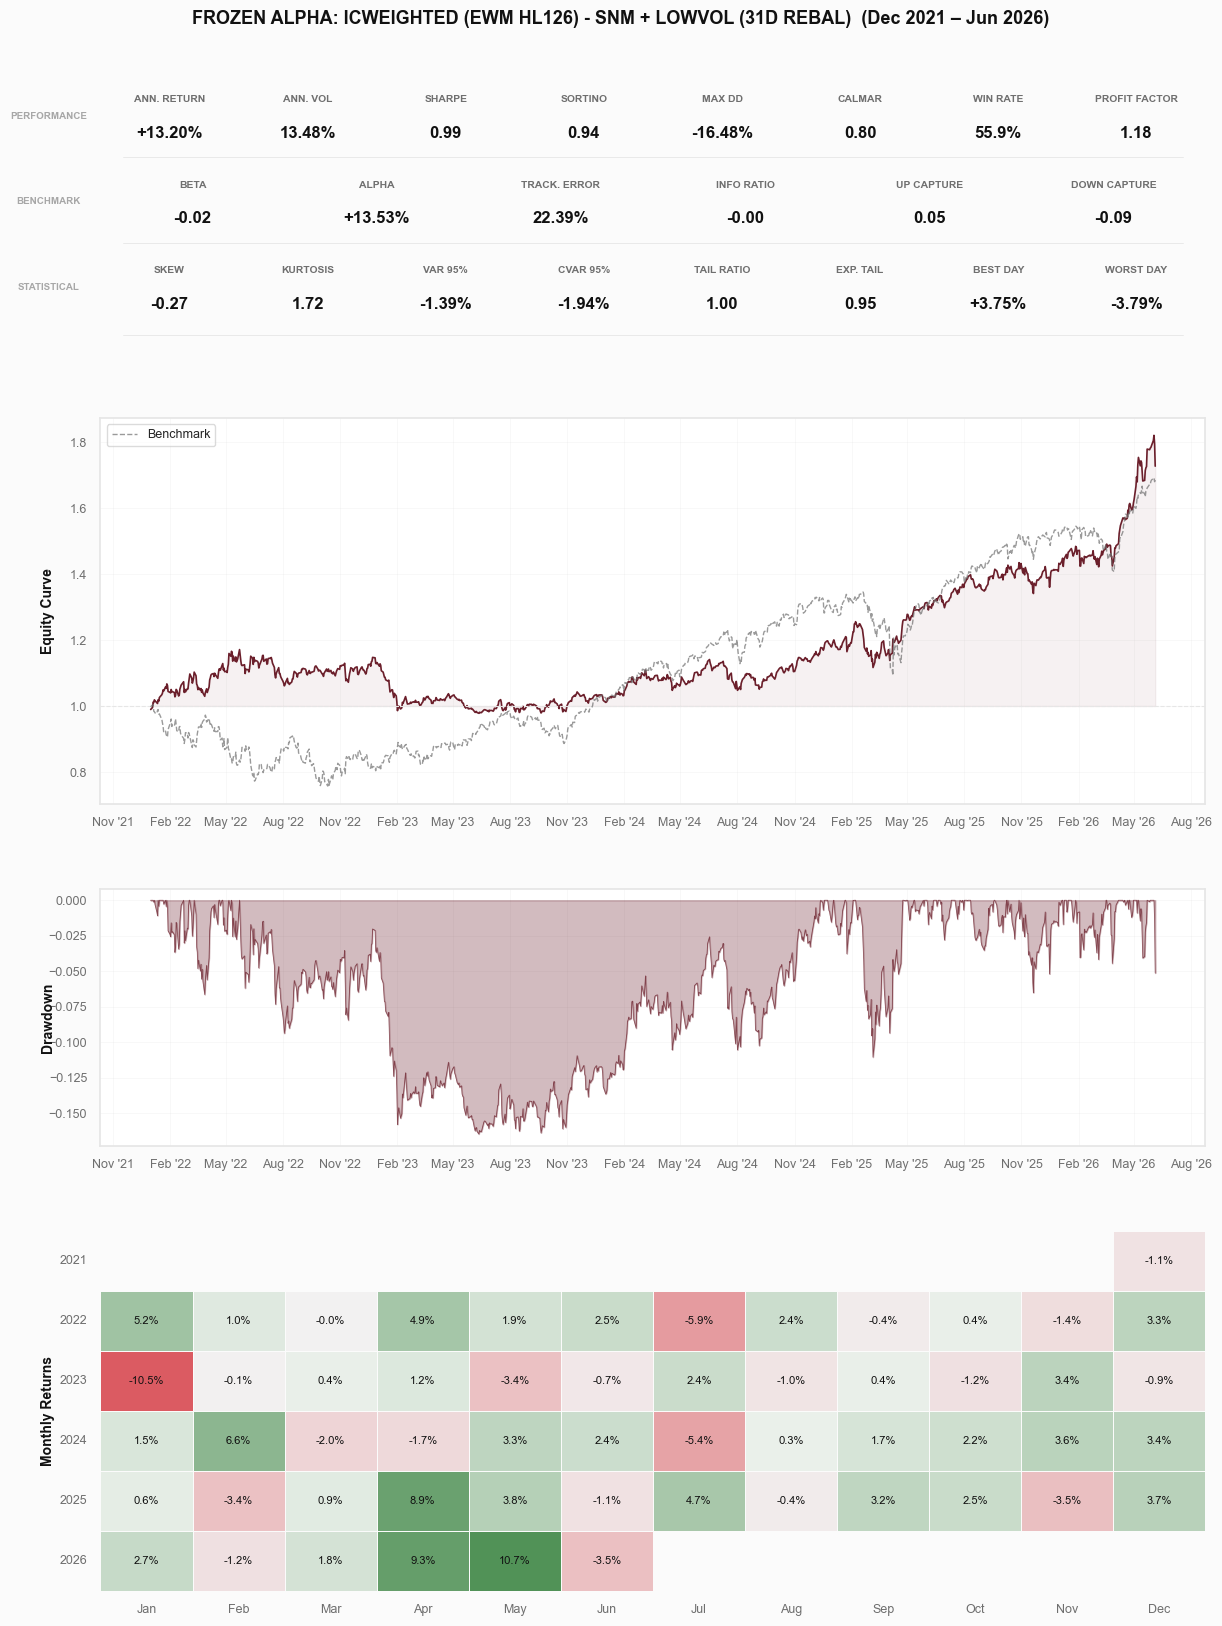

In [ ]:
# Signed IC-weighting (EWM, halflife=126) of SectorNeutralMom + LowVol, 31d rebalance.
# EWM hl126 (4.8.2) is the strongest variant found.
FROZEN_INPUTS = {"SectorNeutralMom": signals["SectorNeutralMom"], "LowVol": signals["LowVol"]}
frozen = ICWeightedCombiner(shrinkage=0.0, use_ewm=True, halflife=126).combine(FROZEN_INPUTS, closes)

# Final regime Sharpes: the frozen alpha vs the Lasso alternative.
cols = ["Sharpe", "Sh_bear", "Sh_trans", "Sh_bull"]
final = pd.DataFrame({
    "FROZEN: ICWeighted EWM-hl126": regime_breakdown(frozen),
    "alt: Lasso (alpha=0.001)":     regime_breakdown(combined["Lasso"]),
}).T[cols]
print("Frozen alpha vs Lasso - regime Sharpes (31d rebal, 10bps):")
print(final.to_string())

# S&P 500 benchmark stats over the same windows (long-only market, not a signal).
spy_daily = closes_all["SPY"].pct_change().loc[common_start:].dropna()
spy_rows = {}
for label, (lo, hi) in {"full": (None, None), **decomp_regimes}.items():
    s = summary(spy_daily.loc[lo:hi])
    spy_rows[label] = {"Sharpe": round(s["sharpe_ratio"], 2),
                       "AnnRet": round(s["annualized_return"], 3),
                       "MaxDD":  round(s["max_drawdown"], 3)}
spy_table = pd.DataFrame(spy_rows).T
print("\nS&P 500 (SPY, long-only) benchmark:")
print(spy_table.to_string())

# Frozen-alpha tear sheet, benchmarked against SPY.
frozen_ret = VectorizedBacktester(cost_bps=10.0, rebalance_freq=FREEZE_HORIZON).run(
    closes_eval, frozen.loc[common_start:])
spy_bench = closes_all["SPY"].pct_change().reindex(frozen_ret.index)
plot_tearsheet(frozen_ret, benchmark_returns=spy_bench,
               title="Frozen alpha: ICWeighted (EWM hl126) - SNM + LowVol (31d rebal)")